Mounted at /content/drive

Modelos por sitio:
sitio
al      33
chon    39
doc     32
ilq     11
nav     15
par     16
sant    16
top     49
Name: modelo_id, dtype: int64

===  REDUNDANCIA GENETICA: TOP 30 REACCIONES POR SITIO ===


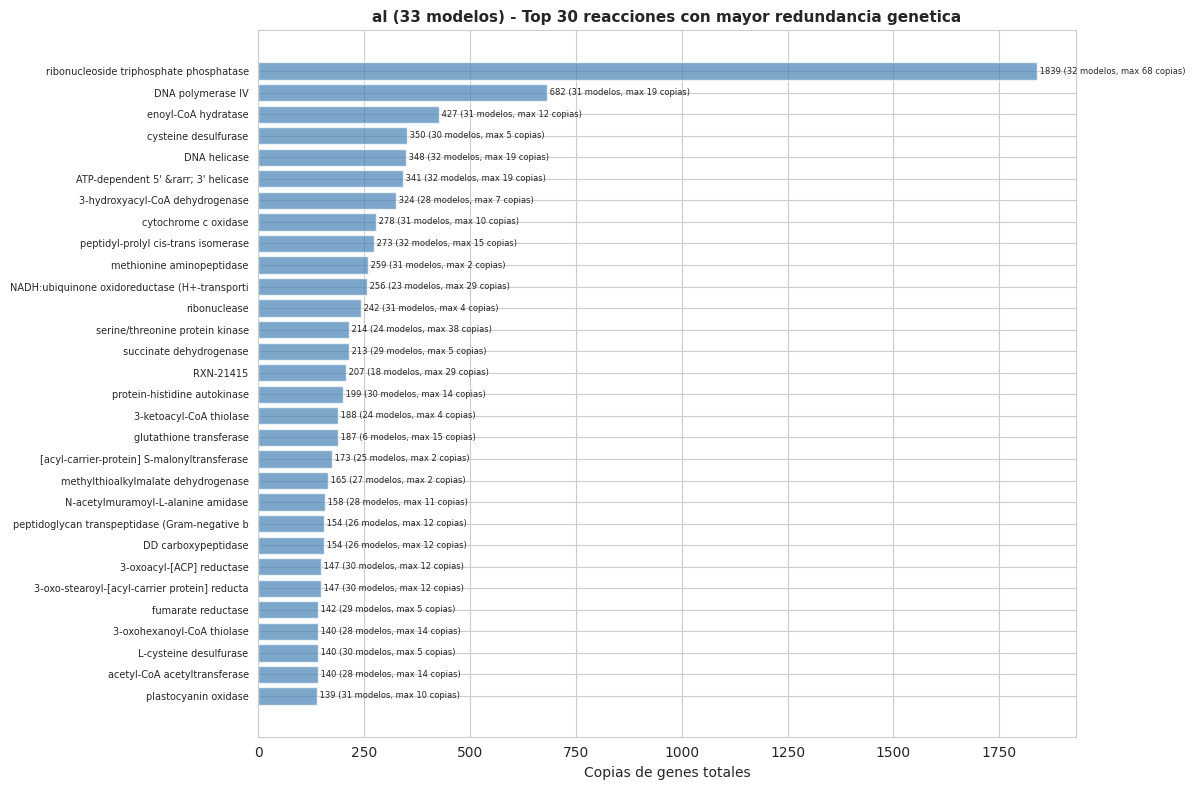

al: guardado


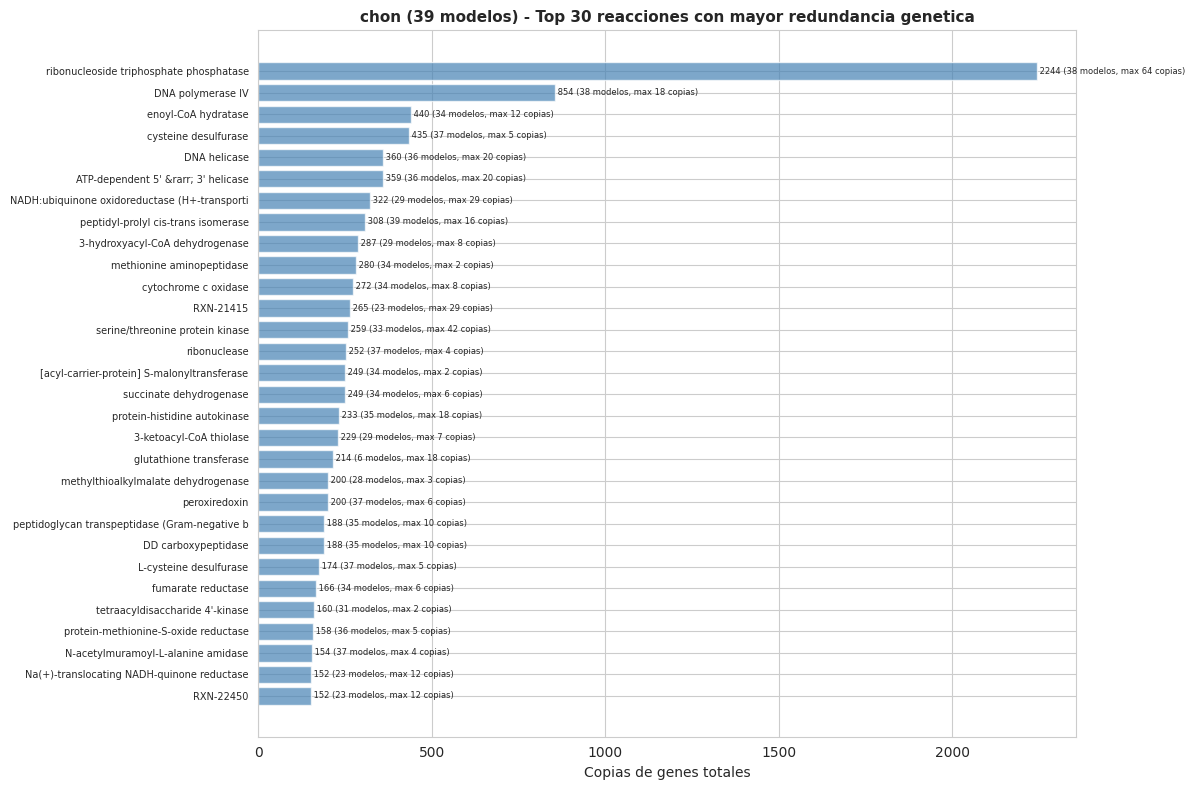

chon: guardado


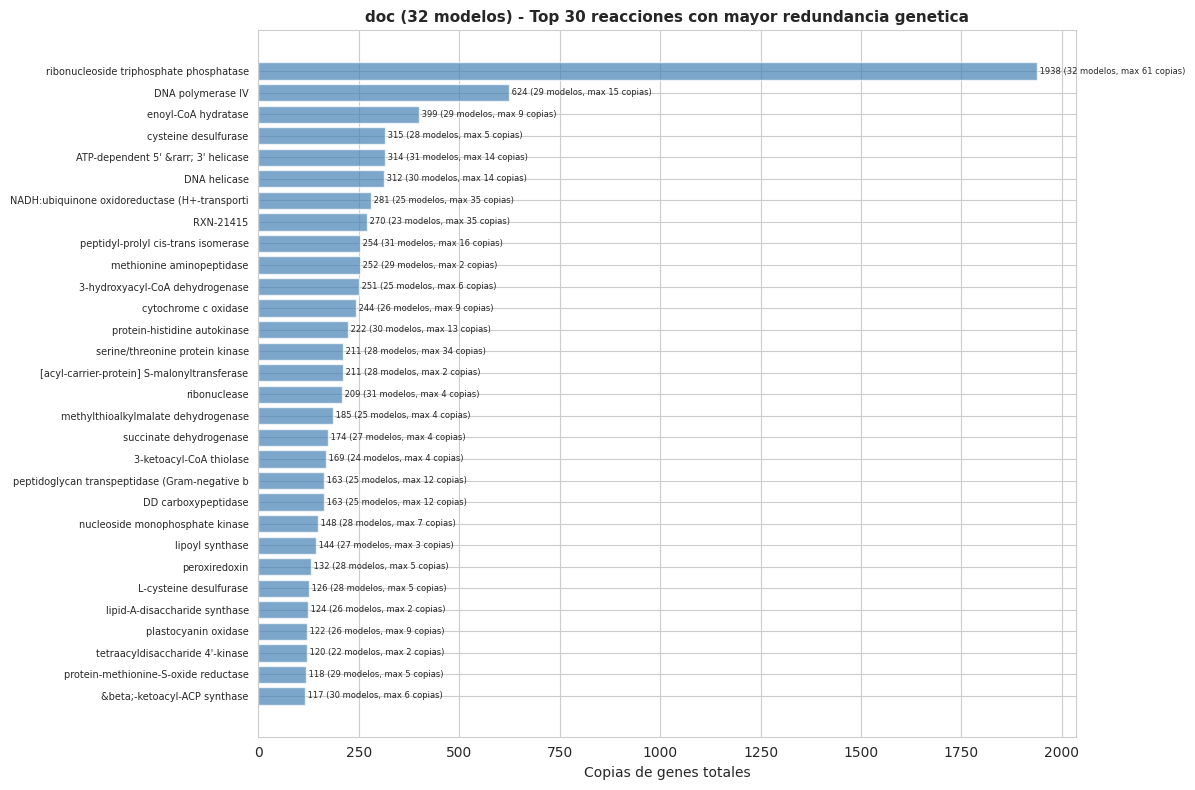

doc: guardado


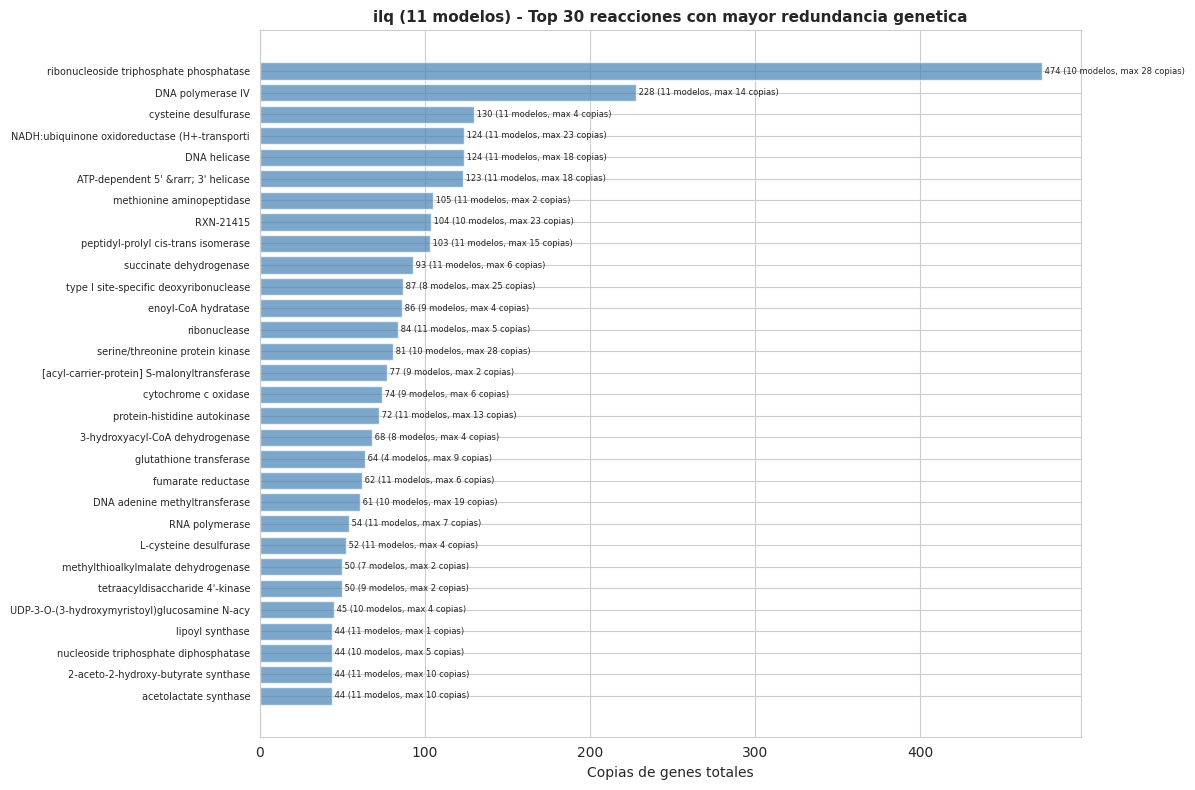

ilq: guardado


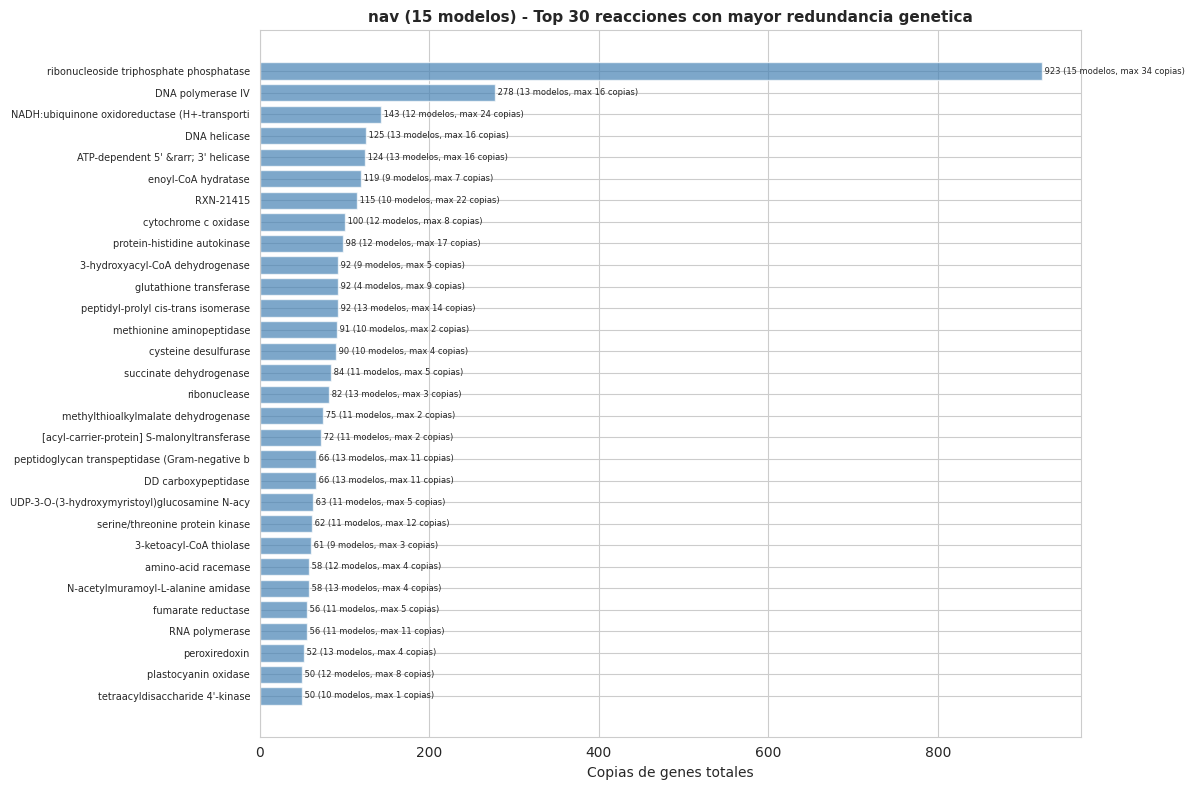

nav: guardado


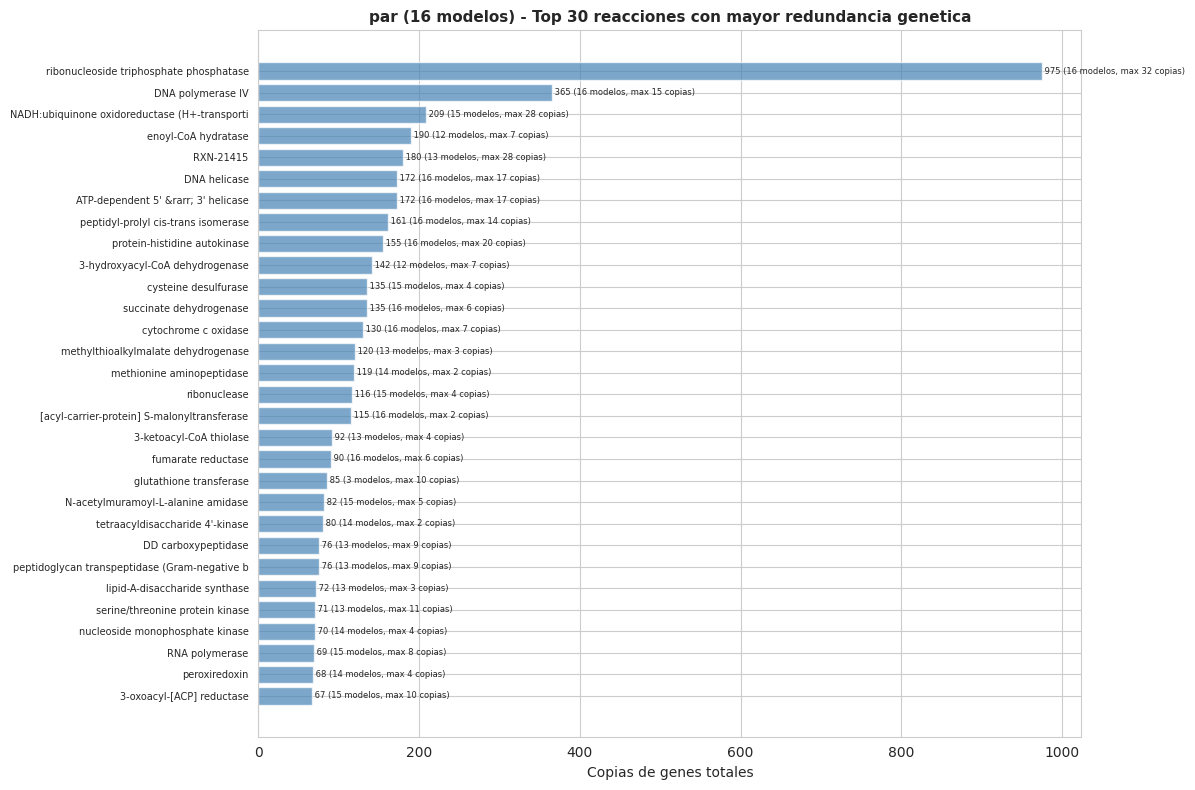

par: guardado


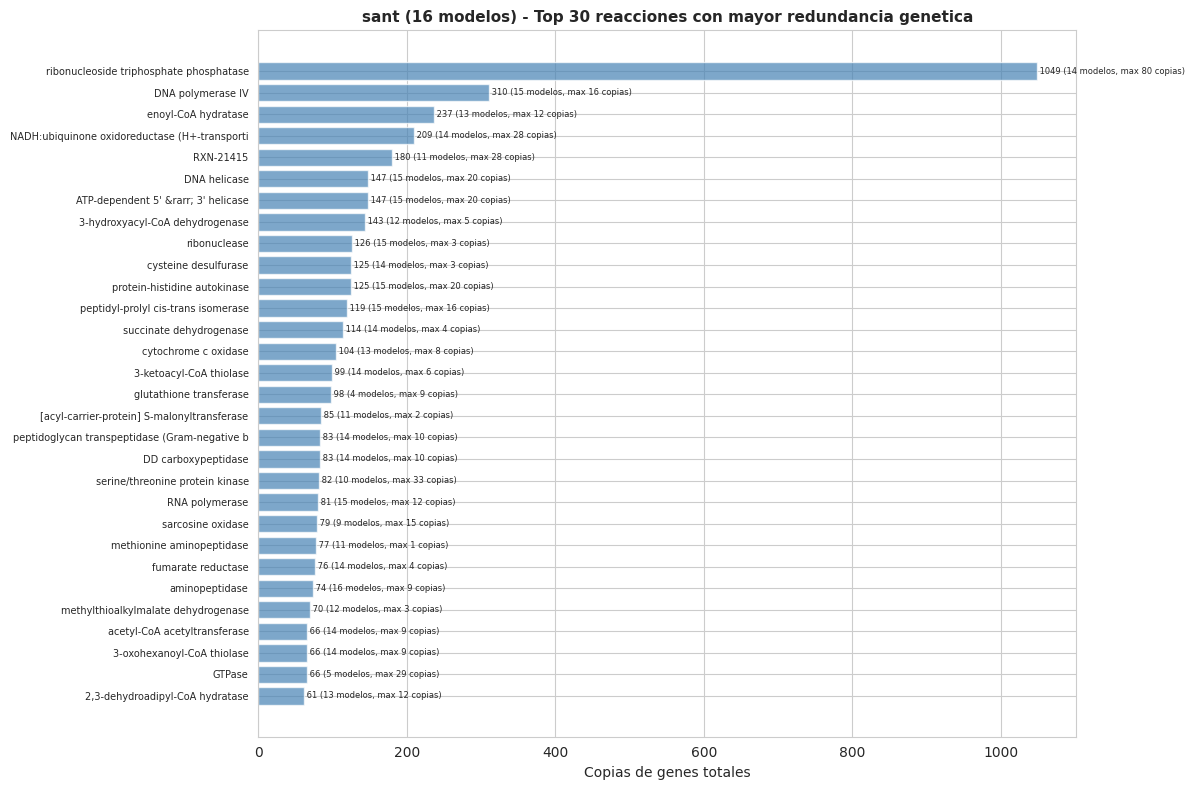

sant: guardado


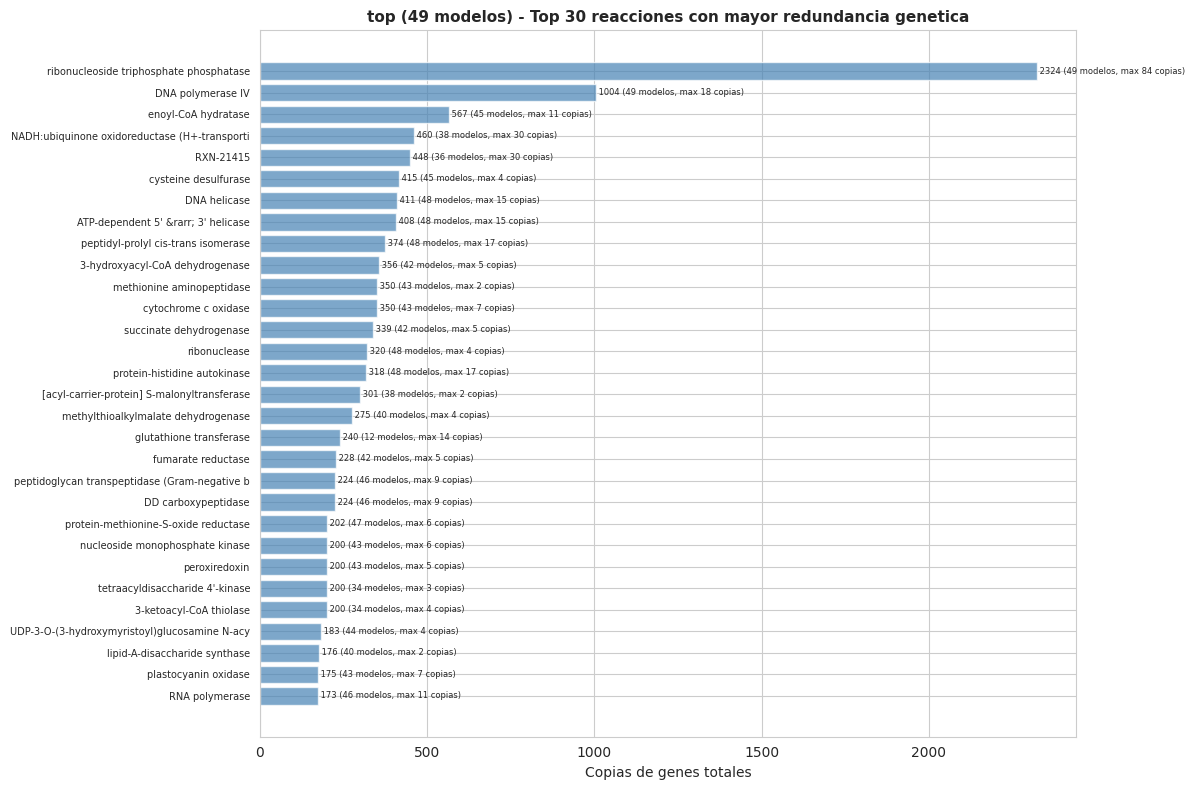

top: guardado

===  REDUNDANCIA GLOBAL: COMPARACION ENTRE SITIOS ===


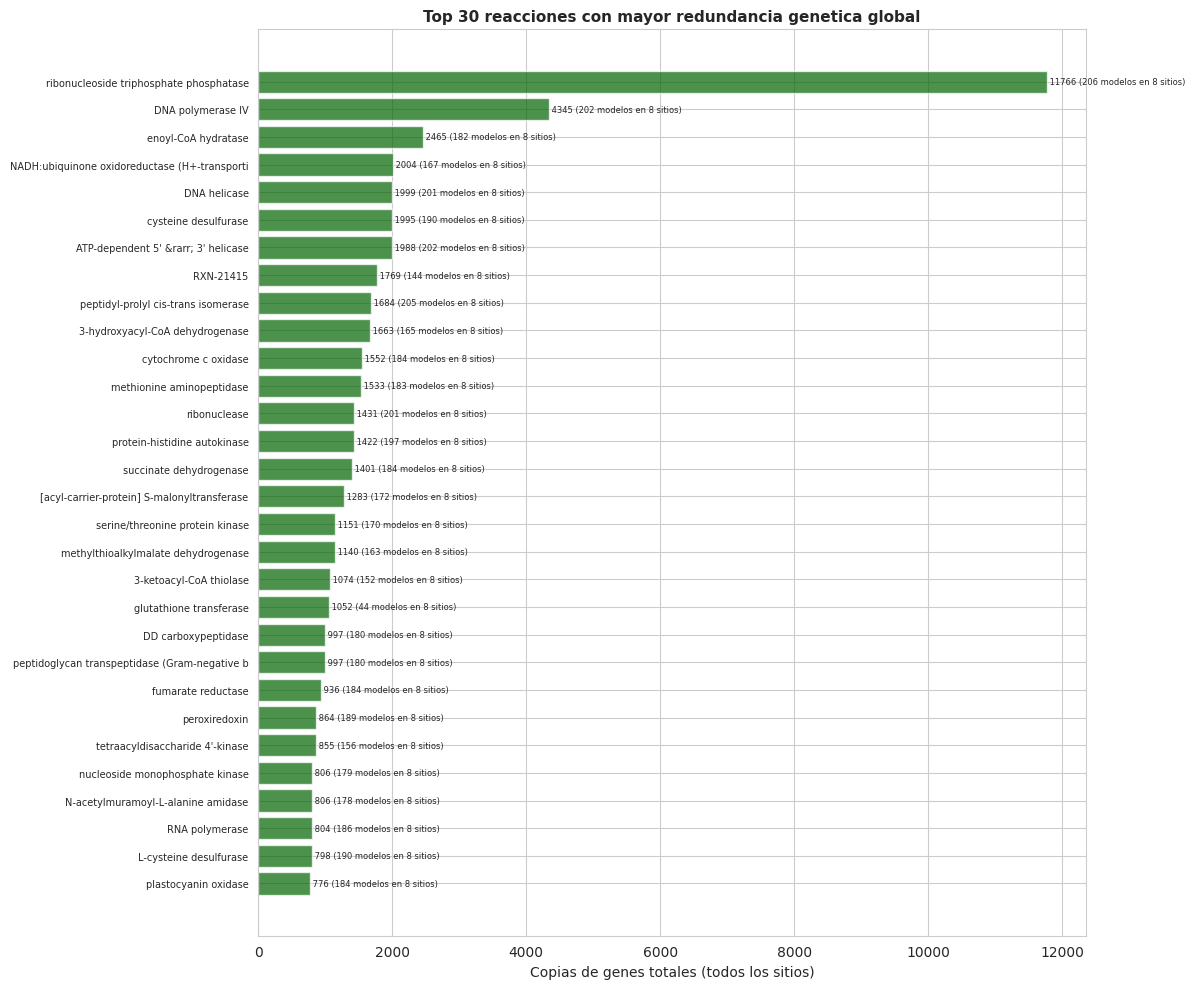

Guardado

===  REACCIONES CONSERVADAS: ALTA PREVALENCIA EN CADA SITIO ===


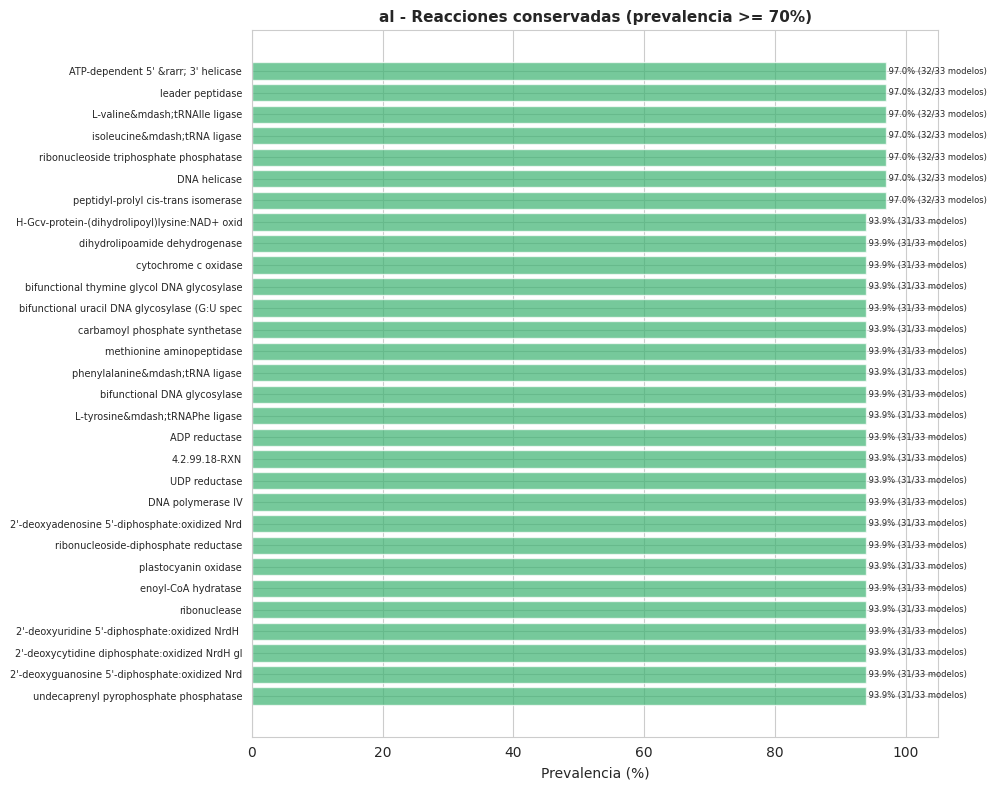

al: 505 conservadas (>= 70%)


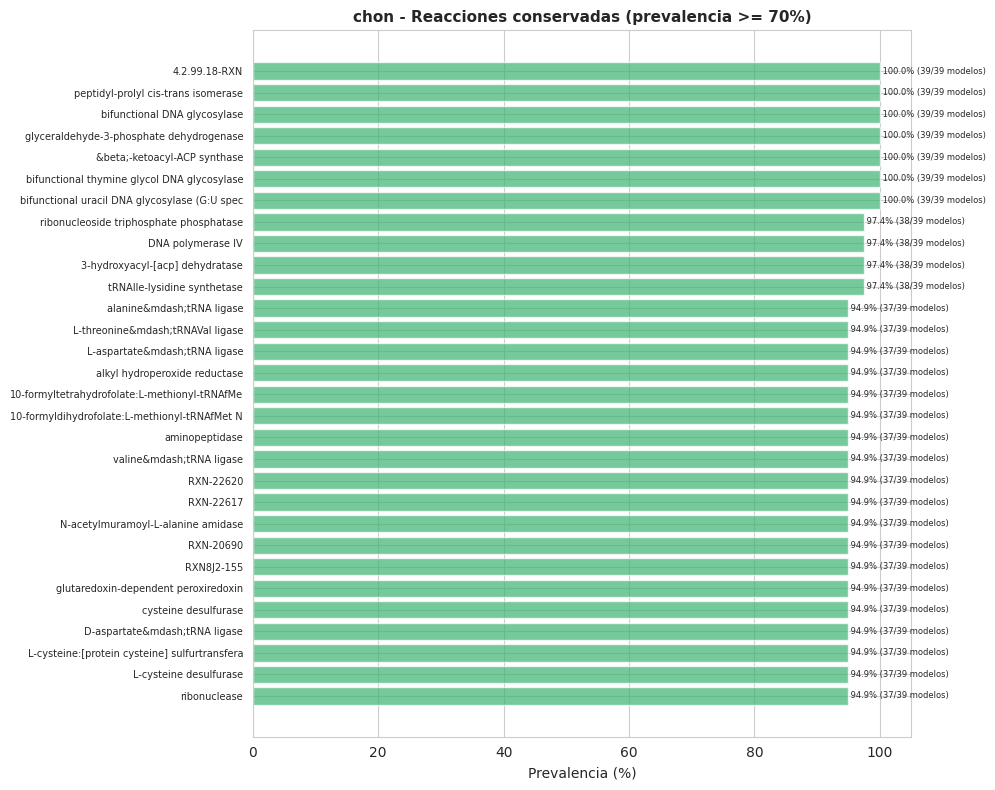

chon: 524 conservadas (>= 70%)


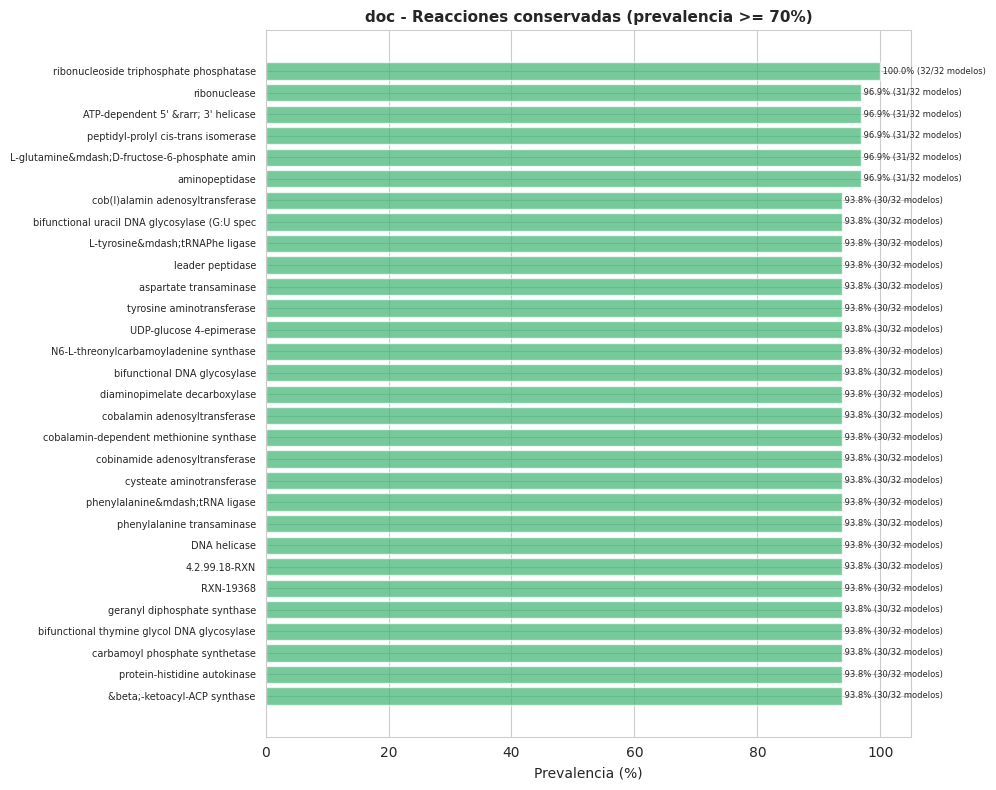

doc: 504 conservadas (>= 70%)


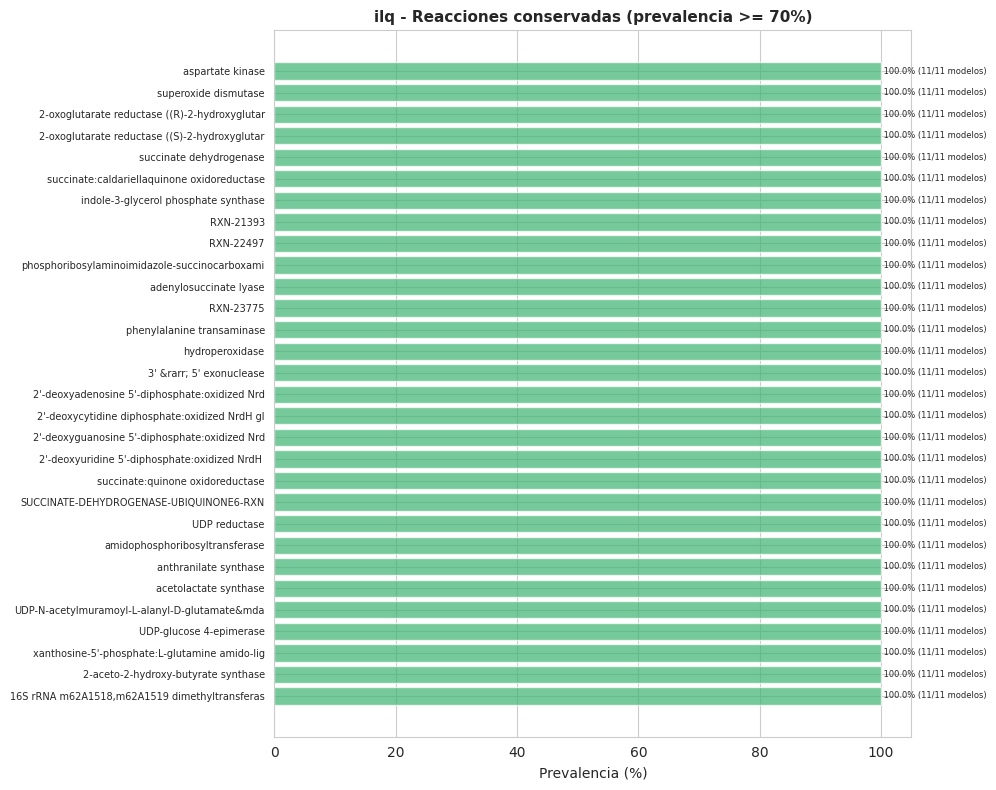

ilq: 579 conservadas (>= 70%)


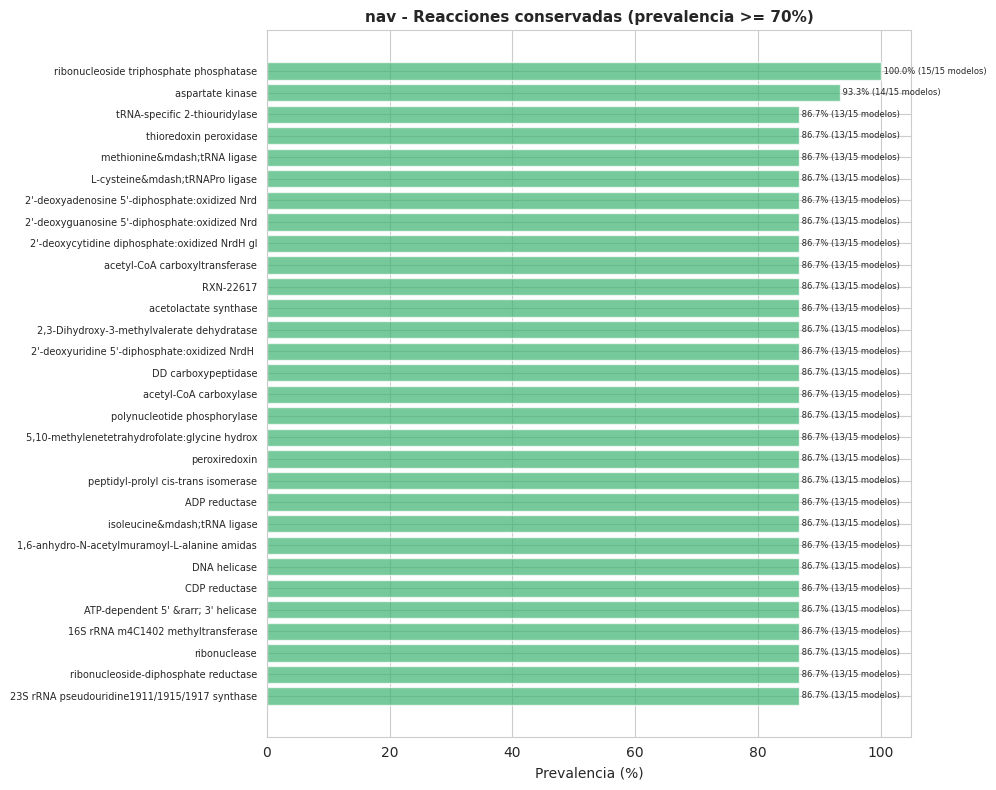

nav: 311 conservadas (>= 70%)


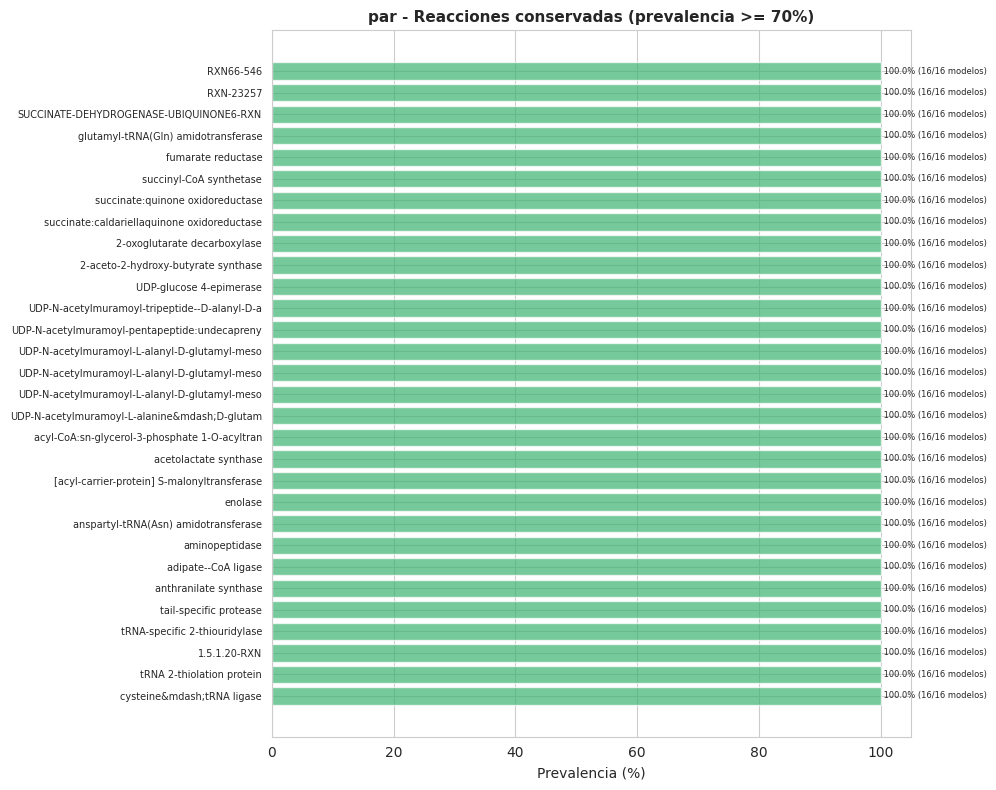

par: 621 conservadas (>= 70%)


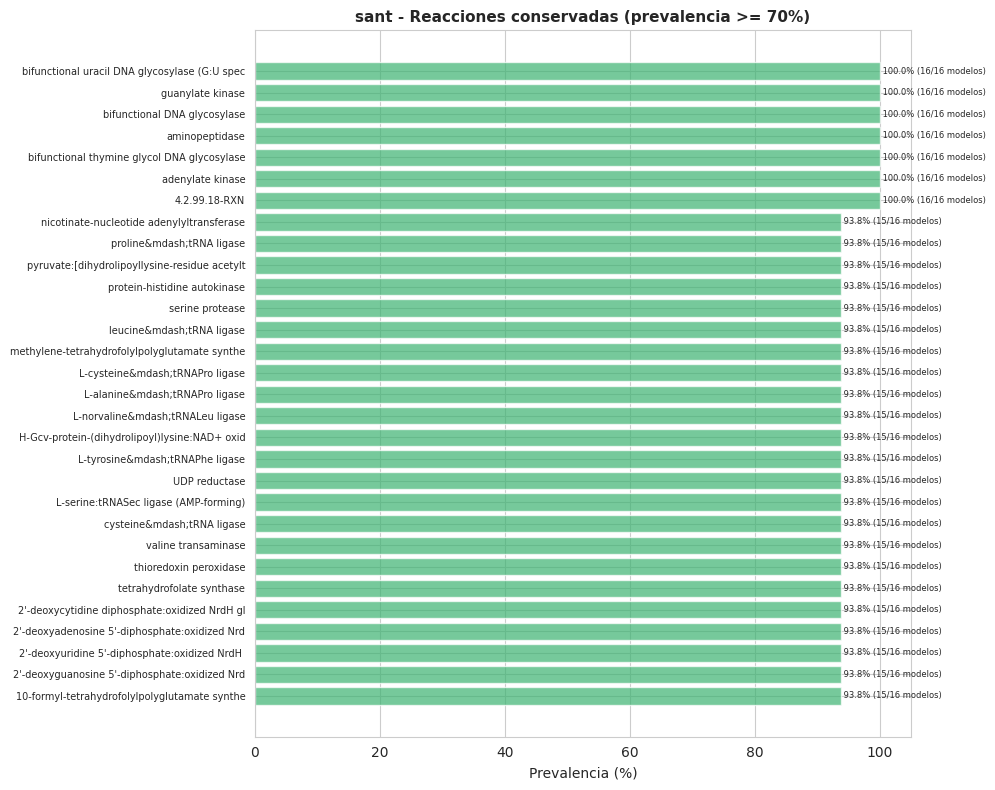

sant: 467 conservadas (>= 70%)


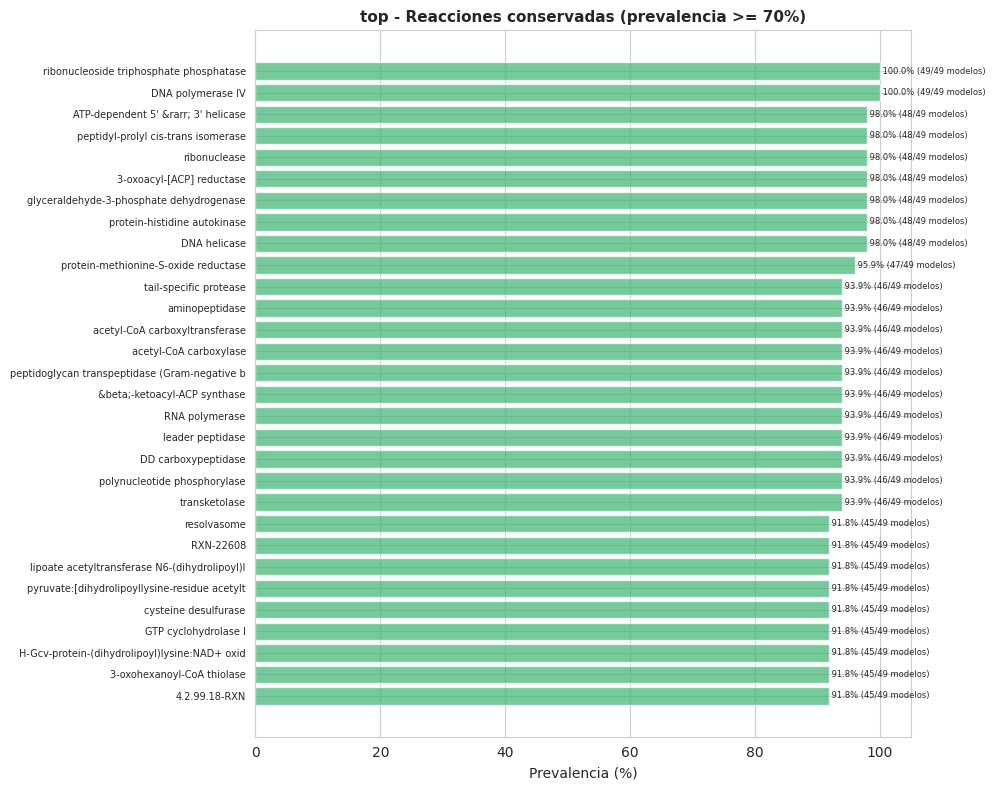

top: 570 conservadas (>= 70%)

===  REACCIONES EXCLUSIVAS POR SITIO ===


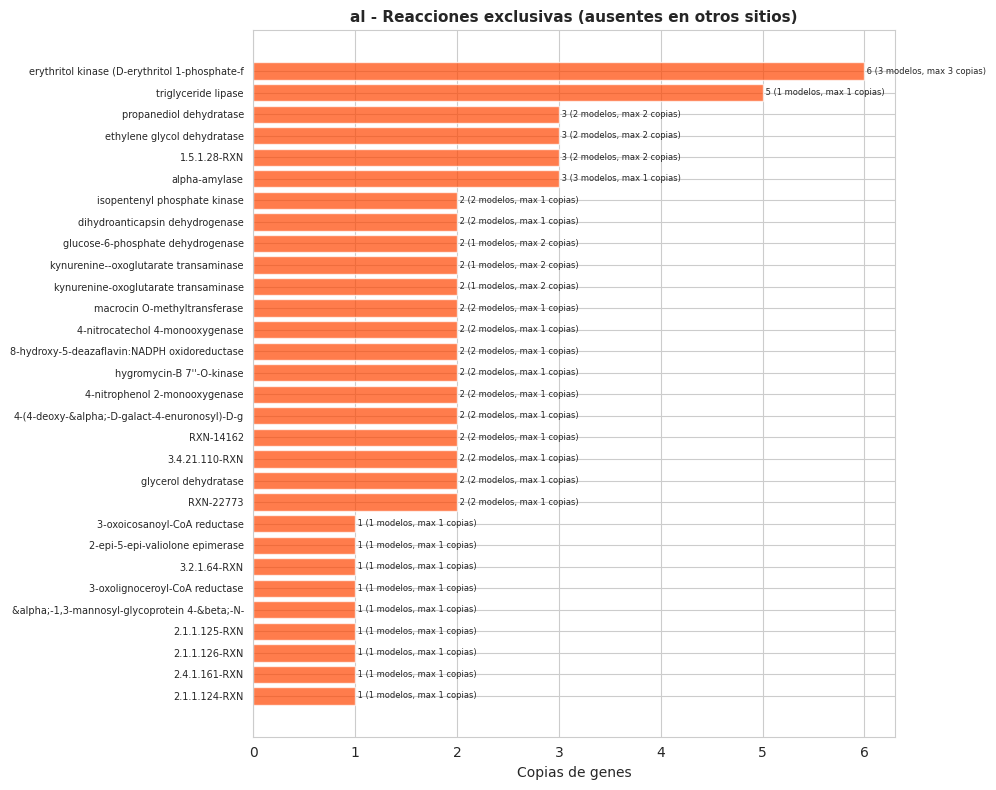

al: 80 exclusivas


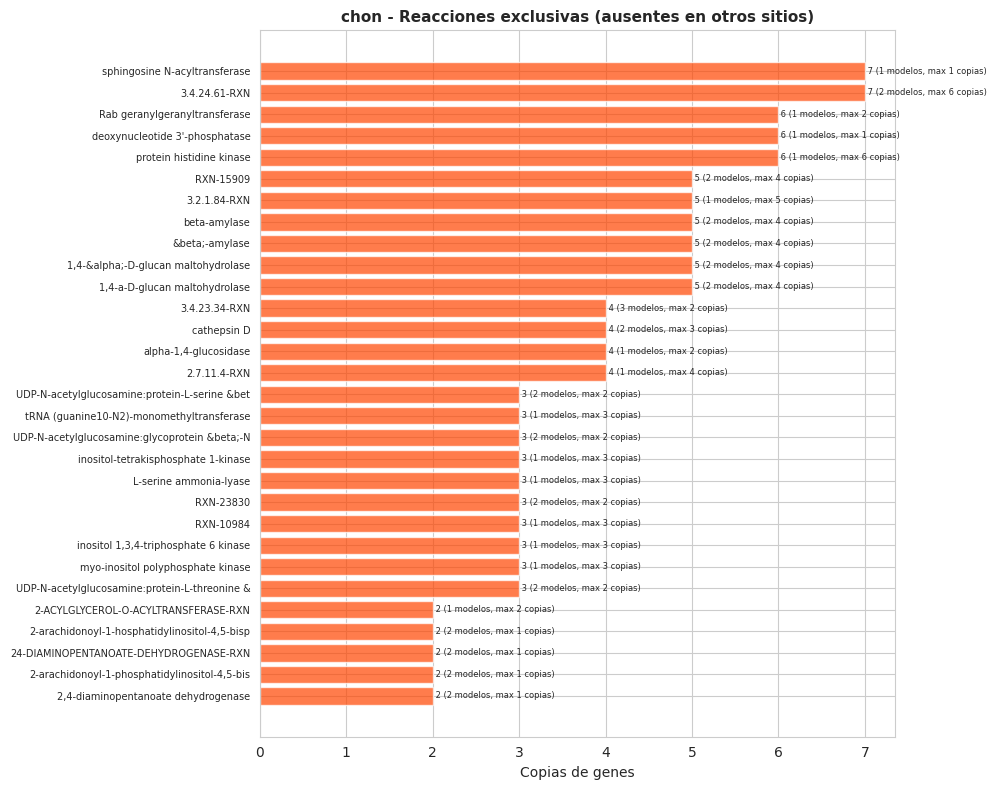

chon: 192 exclusivas


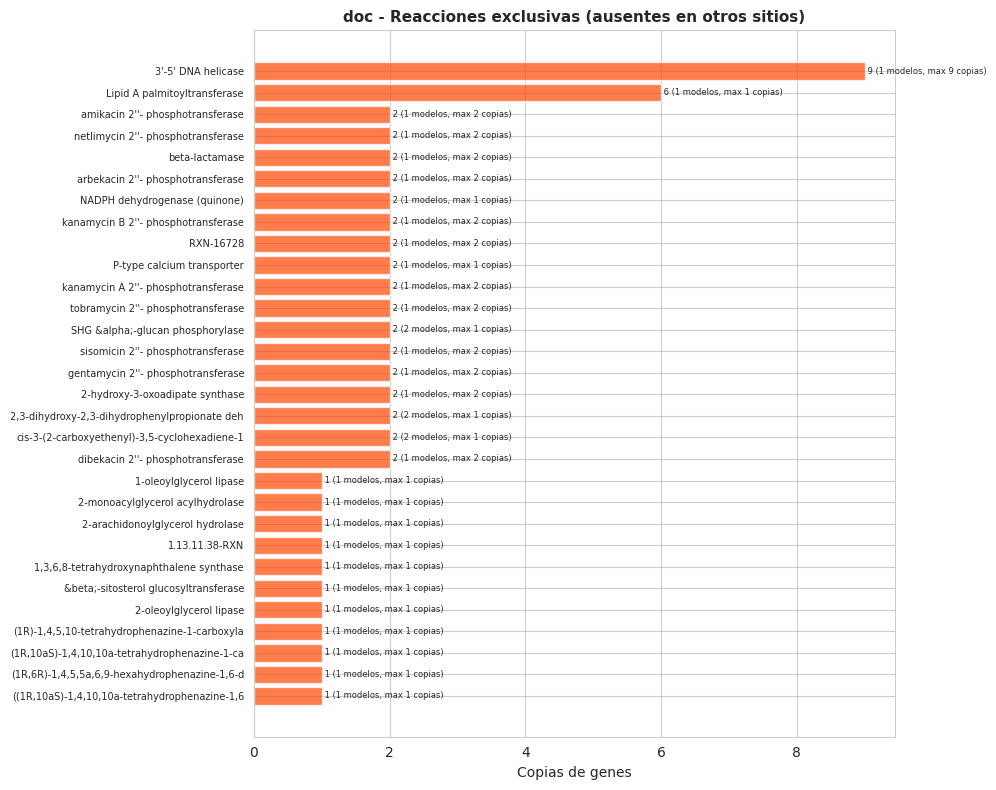

doc: 79 exclusivas


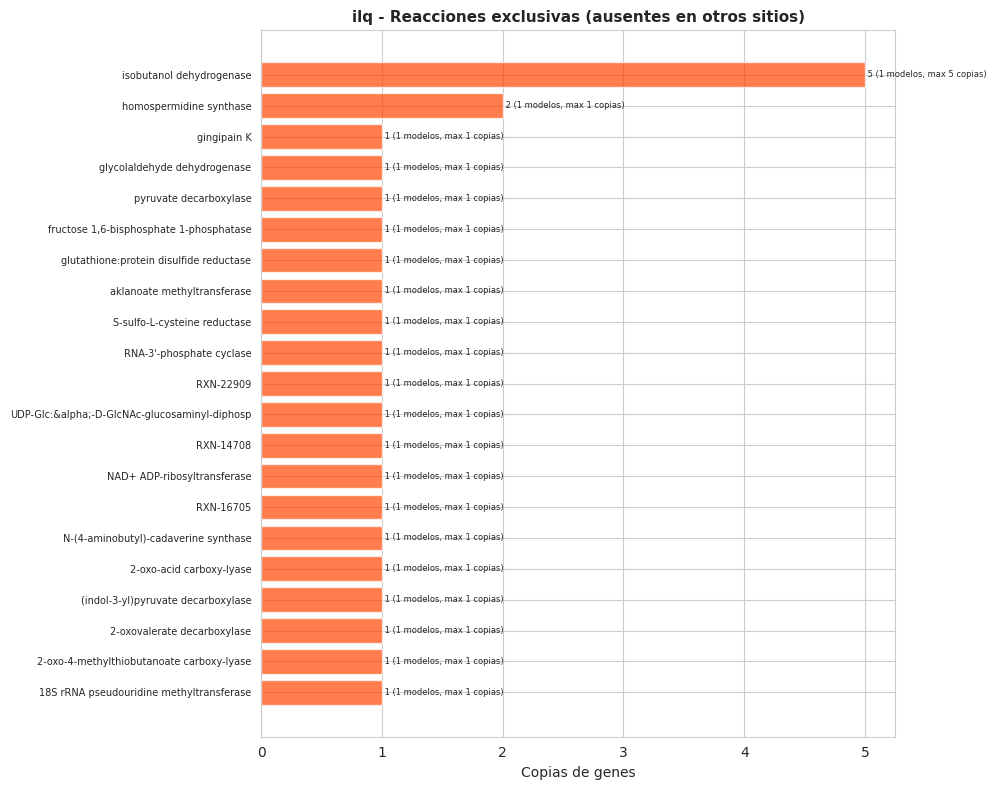

ilq: 21 exclusivas


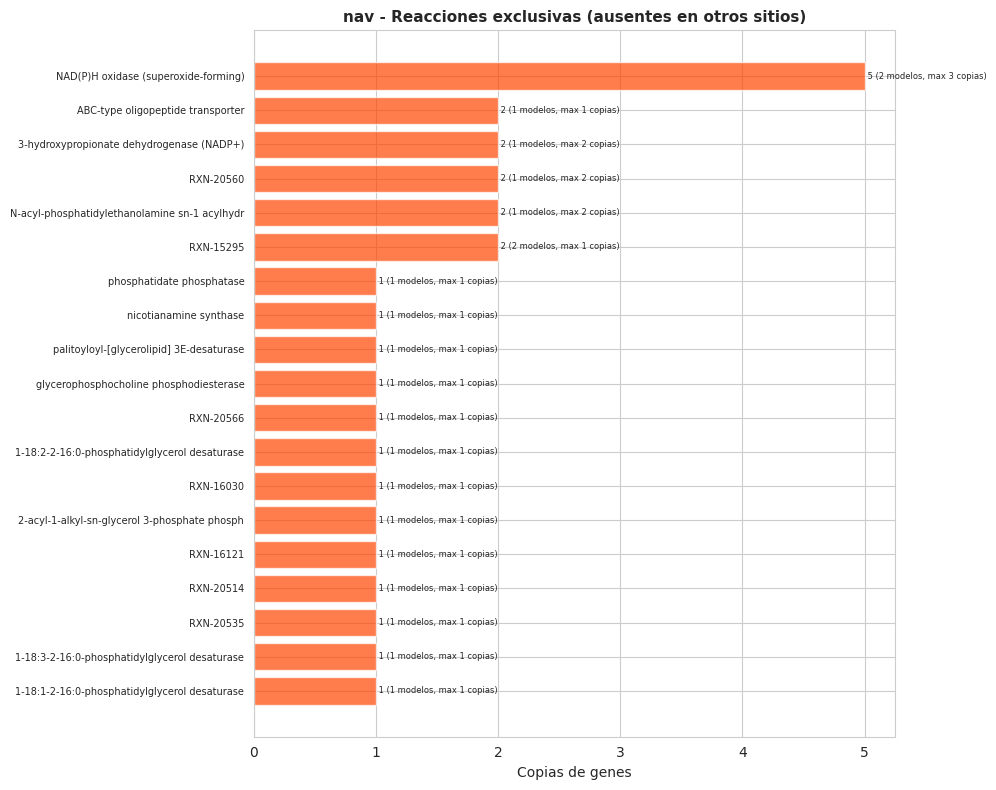

nav: 19 exclusivas


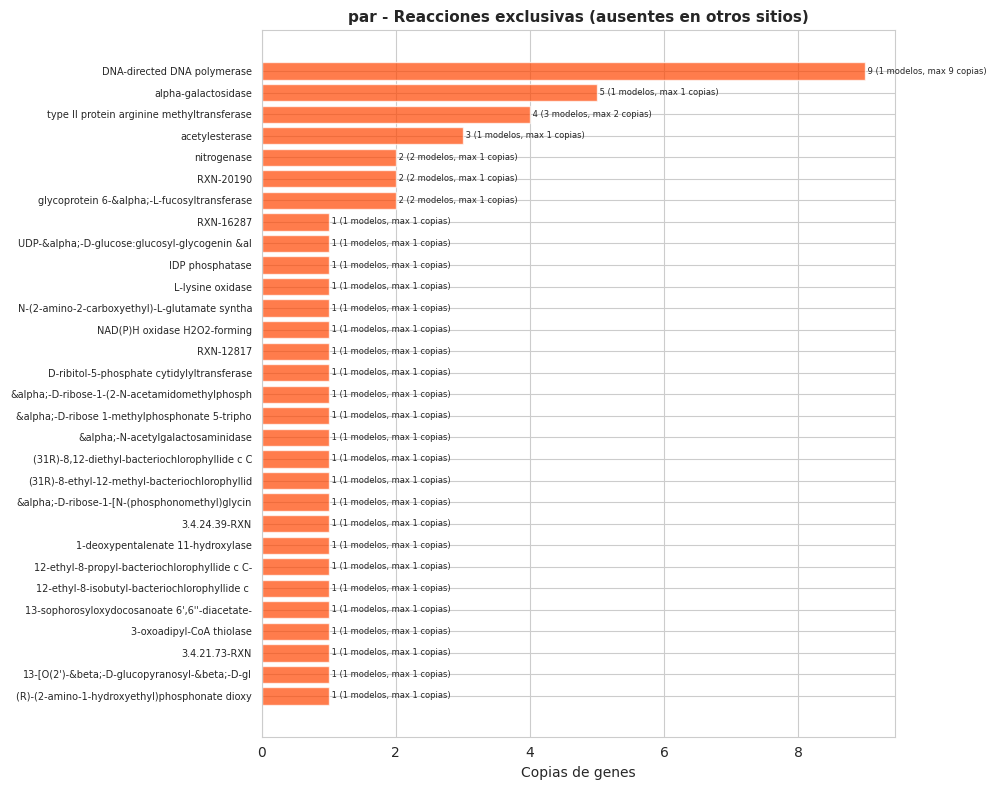

par: 55 exclusivas


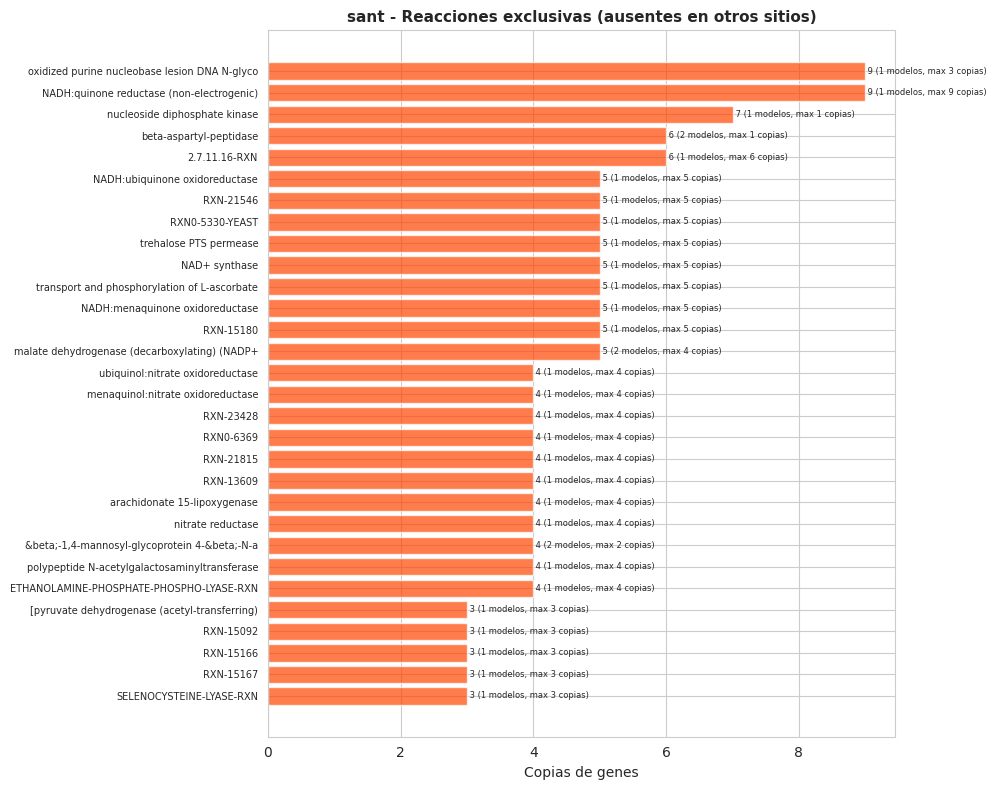

sant: 113 exclusivas


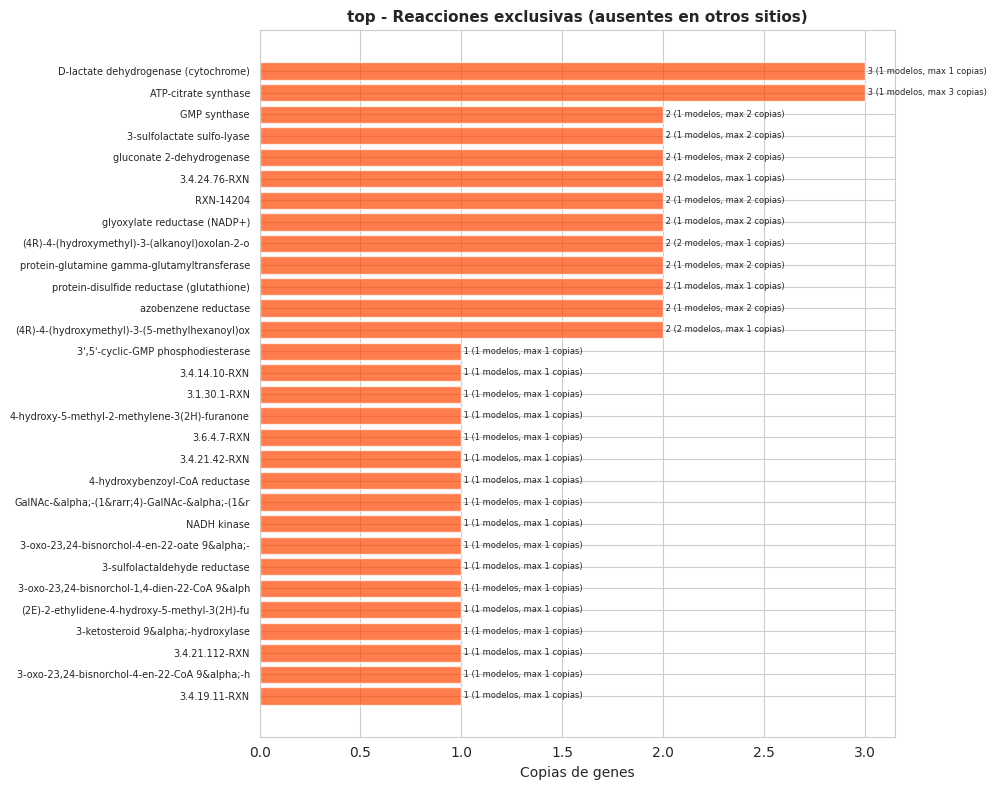

top: 62 exclusivas


/tmp/ipython-input-2910971281.py:279: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xtick_labels, rotation=45, ha='right')


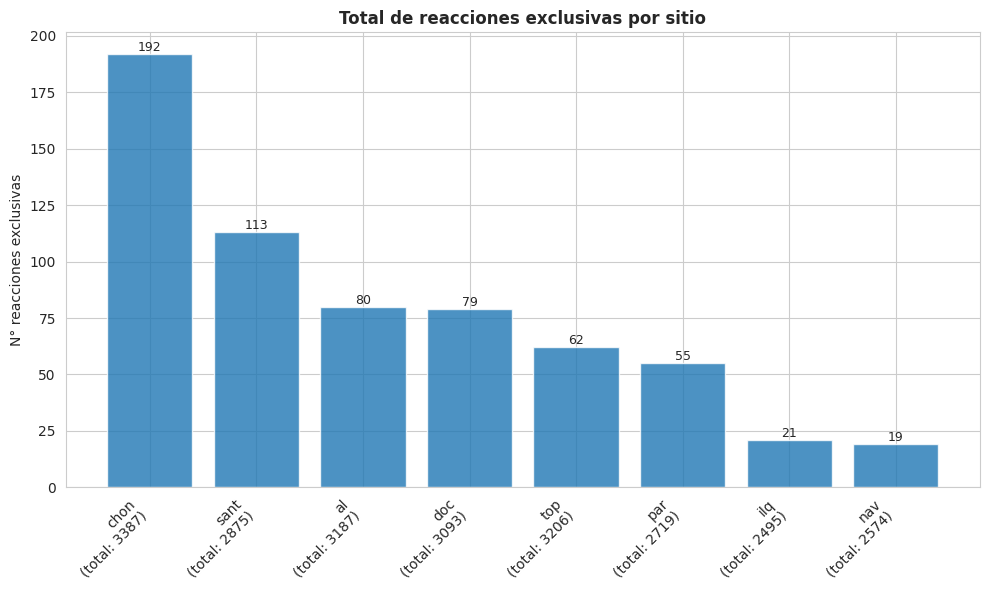

Resumen de exclusivas por sitio guardado


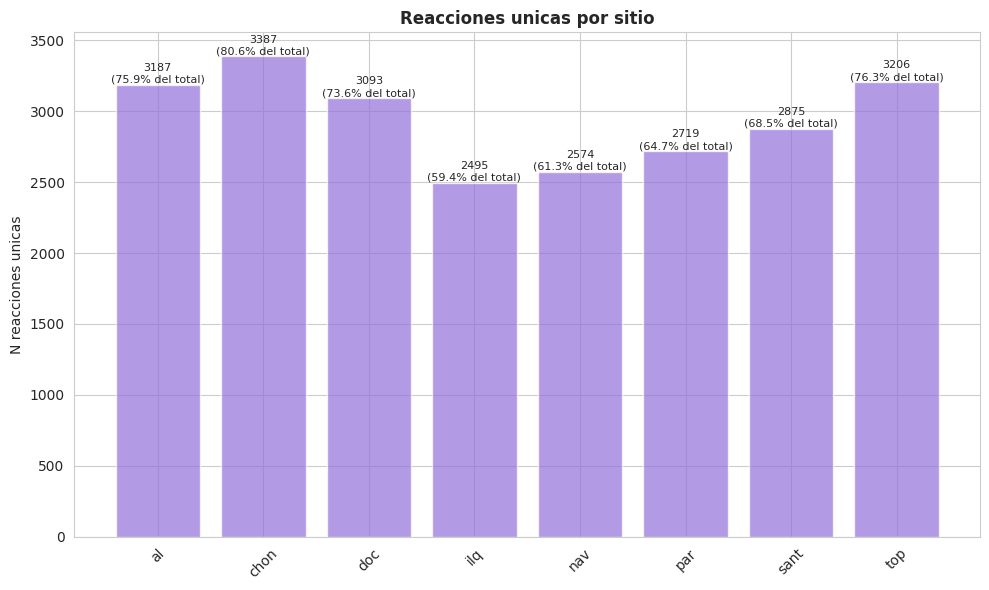

Reacciones unicas guardado


In [1]:
# Este codigo analiza un CSV (generado por el script "CSV_filtrado"), produciendo tablas CSV de resumen y graficos
# Se analizan las reacciones y sus genes asociados segun sitio (hay 8 localidades) y de forma global
# Para este analisis se considera que las reglas GPR de los 211 modelos solo son "OR" y no "AND"
# En este caso, para perder cierta reaccion, se deben eliminar el mismo numero de copias de genes asociados a esa reaccion


from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

# Definir el CSV a analizar
CSV_PATH = "/content/drive/MyDrive/MASH_primavera_2025/out/run_20260106_001334/reacciones_completo.csv"
OUT_DIR = "/content/drive/MyDrive/MASH_primavera_2025/out/run_20260106_001334/analisis_redundancia"
os.makedirs(OUT_DIR, exist_ok=True)

# Funcion principal para llamar al CSV
df = pd.read_csv(CSV_PATH, encoding='utf-8')
df.columns = df.columns.str.strip()

sitios = sorted(df['sitio'].unique())

# Informacion general de modelos por sitio
n_modelos_por_sitio = df.groupby('sitio')['modelo_id'].nunique()
print("\nModelos por sitio:")
print(n_modelos_por_sitio)

# ========== REDUNDANCIA GENETICA POR SITIO ==========
print("\n===  REDUNDANCIA GENETICA: TOP 30 REACCIONES POR SITIO ===")

for sitio in sitios:
    df_s = df[df['sitio'] == sitio].copy()
    n_modelos = df_s['modelo_id'].nunique()

    # Analisis por reaccion
    rxn_analisis = df_s.groupby('rxn_nombre').agg(
        n_modelos=('modelo_id', 'nunique'),
        n_filas=('rxn_id', 'count'),
        genes_total=('min_deleciones', 'sum'),
        genes_min=('min_deleciones', 'min'),
        genes_max=('min_deleciones', 'max'),
        genes_mediana=('min_deleciones', 'median'),
        genes_promedio=('min_deleciones', 'mean'),
        subsystem=('subsystem', 'first'),
        ec=('ec', 'first')
    ).reset_index()

    # Calcular metricas de redundancia
    rxn_analisis['prevalencia_pct'] = (rxn_analisis['n_modelos'] / n_modelos) * 100
    rxn_analisis['genes_por_modelo'] = rxn_analisis['genes_total'] / rxn_analisis['n_modelos']

    # Ordenar por redundancia total
    rxn_analisis = rxn_analisis.sort_values(['genes_total', 'n_modelos'], ascending=[False, False])

    # Top 30 (PUEDE VARIAR NUMERO)
    top30 = rxn_analisis.head(30).copy() # extension
    top30.to_csv(f"{OUT_DIR}/1_redundancia_top30_{sitio}.csv", index=False)

    # Grafico
    fig, ax = plt.subplots(figsize=(12, 8))
    top30_plot = top30.sort_values('genes_total', ascending=True)
    y = np.arange(len(top30_plot))

    ax.barh(y, top30_plot['genes_total'], color='steelblue', alpha=0.7)
    ax.set_yticks(y)
    ax.set_yticklabels([n[:45] for n in top30_plot['rxn_nombre']], fontsize=7)
    ax.set_xlabel('Copias de genes totales')
    ax.set_title(f'{sitio} ({n_modelos} modelos) - Top 30 reacciones con mayor redundancia genetica',
                 fontweight='bold', fontsize=11)

    for i, row in enumerate(top30_plot.itertuples()):
        label = f"{int(row.genes_total)} ({row.n_modelos} modelos, max {int(row.genes_max)} copias)"
        ax.text(row.genes_total, i, f' {label}', va='center', fontsize=6)

    plt.tight_layout()
    plt.savefig(f"{OUT_DIR}/1_redundancia_top30_{sitio}.png", dpi=300, bbox_inches='tight')
    plt.show()

    print(f"{sitio}: guardado")

# ==========  REDUNDANCIA GLOBAL (COMPARACION ENTRE SITIOS) ==========
print("\n===  REDUNDANCIA GLOBAL: COMPARACION ENTRE SITIOS ===")

redundancia_comparativa = []

for sitio in sitios:
    df_s = df[df['sitio'] == sitio].copy()
    n_modelos = df_s['modelo_id'].nunique()

    rxn_sitio = df_s.groupby('rxn_nombre').agg(
        n_modelos=('modelo_id', 'nunique'),
        genes_total=('min_deleciones', 'sum')
    ).reset_index()

    rxn_sitio['sitio'] = sitio
    rxn_sitio['prevalencia_pct'] = (rxn_sitio['n_modelos'] / n_modelos) * 100

    redundancia_comparativa.append(rxn_sitio)

df_comp = pd.concat(redundancia_comparativa, ignore_index=True)

# Top 30 reacciones mas redundantes globalmente
rxn_global = df_comp.groupby('rxn_nombre').agg(
    genes_total_global=('genes_total', 'sum'),
    sitios_presentes=('sitio', 'nunique'),
    n_modelos_total=('n_modelos', 'sum')
).reset_index().sort_values('genes_total_global', ascending=False)

 # PUEDE VARIAR NUMERO
top30_global = rxn_global.head(30).copy() # extension
top30_global.to_csv(f"{OUT_DIR}/2_redundancia_global_top30.csv", index=False)

# Grafico global
fig, ax = plt.subplots(figsize=(12, 10))
top30_plot = top30_global.sort_values('genes_total_global', ascending=True)
y = np.arange(len(top30_plot))

ax.barh(y, top30_plot['genes_total_global'], color='darkgreen', alpha=0.7)
ax.set_yticks(y)
ax.set_yticklabels([n[:45] for n in top30_plot['rxn_nombre']], fontsize=7)
ax.set_xlabel('Copias de genes totales (todos los sitios)')
ax.set_title('Top 30 reacciones con mayor redundancia genetica global', fontweight='bold', fontsize=11)

for i, row in enumerate(top30_plot.itertuples()):
    label = f"{int(row.genes_total_global)} ({row.n_modelos_total} modelos en {row.sitios_presentes} sitios)"
    ax.text(row.genes_total_global, i, f' {label}', va='center', fontsize=6)

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/2_redundancia_global_top30.png", dpi=300, bbox_inches='tight')
plt.show()

print("Guardado")


# ==========  REACCIONES CONSERVADAS (ALTA PREVALENCIA) ==========
print("\n===  REACCIONES CONSERVADAS: ALTA PREVALENCIA EN CADA SITIO ===")

for sitio in sitios:
    df_s = df[df['sitio'] == sitio].copy()
    n_modelos = df_s['modelo_id'].nunique()

    rxn_prev = df_s.groupby('rxn_nombre').agg(
        n_modelos=('modelo_id', 'nunique'),
        genes_total=('min_deleciones', 'sum'),
        genes_max=('min_deleciones', 'max'),
        subsystem=('subsystem', 'first')
    ).reset_index()

    rxn_prev['prevalencia_pct'] = (rxn_prev['n_modelos'] / n_modelos) * 100

    # Filtrar: presente en al menos 70% de modelos del sitio
    conservadas = rxn_prev[rxn_prev['prevalencia_pct'] >= 70].sort_values('prevalencia_pct', ascending=False)

    top30_cons = conservadas.head(30).copy() # extension
    top30_cons.to_csv(f"{OUT_DIR}/4_conservadas_{sitio}.csv", index=False)

    # Grafico
    fig, ax = plt.subplots(figsize=(10, 8))
    top30_plot = top30_cons.sort_values('prevalencia_pct', ascending=True)
    y = np.arange(len(top30_plot))

    ax.barh(y, top30_plot['prevalencia_pct'], color='mediumseagreen', alpha=0.7)
    ax.set_yticks(y)
    ax.set_yticklabels([n[:45] for n in top30_plot['rxn_nombre']], fontsize=7)
    ax.set_xlabel('Prevalencia (%)')
    ax.set_title(f'{sitio} - Reacciones conservadas (prevalencia >= 70%)', fontweight='bold', fontsize=11)
    ax.set_xlim([0, 105])

    for i, row in enumerate(top30_plot.itertuples()):
        label = f"{row.prevalencia_pct:.1f}% ({row.n_modelos}/{n_modelos} modelos)"
        ax.text(row.prevalencia_pct, i, f' {label}', va='center', fontsize=6)

    plt.tight_layout()
    plt.savefig(f"{OUT_DIR}/4_conservadas_{sitio}.png", dpi=300, bbox_inches='tight')
    plt.show()

    print(f"{sitio}: {len(conservadas)} conservadas (>= 70%)")




# ==========  REACCIONES EXCLUSIVAS (PRESENTES SOLO EN UN SITIO) ==========
print("\n===  REACCIONES EXCLUSIVAS POR SITIO ===")

# NUEVO: acumulador para resumen por sitio
exclusivas_resumen = []

for sitio in sitios:
    rxn_sitio = set(df[df['sitio'] == sitio]['rxn_nombre'].unique())
    rxn_otros = set(df[df['sitio'] != sitio]['rxn_nombre'].unique())
    exclusivas = rxn_sitio - rxn_otros

    # NUEVO: guardar conteo total de exclusivas por sitio (aunque sea 0)
    exclusivas_resumen.append({
        "sitio": sitio,
        "n_exclusivas": len(exclusivas)
    })

    if exclusivas:
        df_excl = df[(df['sitio'] == sitio) & (df['rxn_nombre'].isin(exclusivas))].copy()

        excl_analisis = df_excl.groupby('rxn_nombre').agg(
            n_modelos=('modelo_id', 'nunique'),
            genes_total=('min_deleciones', 'sum'),
            genes_max=('min_deleciones', 'max'),
            subsystem=('subsystem', 'first'),
            ec=('ec', 'first')
        ).reset_index().sort_values('genes_total', ascending=False)

        top30_excl = excl_analisis.head(30).copy()
        top30_excl.to_csv(f"{OUT_DIR}/3_exclusivas_{sitio}.csv", index=False)

        # Grafico top30 exclusivas (por sitio)
        fig, ax = plt.subplots(figsize=(10, 8))
        top30_plot = top30_excl.sort_values('genes_total', ascending=True)
        y = np.arange(len(top30_plot))

        ax.barh(y, top30_plot['genes_total'], color='orangered', alpha=0.7)
        ax.set_yticks(y)
        ax.set_yticklabels([n[:45] for n in top30_plot['rxn_nombre']], fontsize=7)
        ax.set_xlabel('Copias de genes')
        ax.set_title(f'{sitio} - Reacciones exclusivas (ausentes en otros sitios)', fontweight='bold', fontsize=11)

        for i, row in enumerate(top30_plot.itertuples()):
            label = f"{int(row.genes_total)} ({row.n_modelos} modelos, max {int(row.genes_max)} copias)"
            ax.text(row.genes_total, i, f' {label}', va='center', fontsize=6)

        plt.tight_layout()
        plt.savefig(f"{OUT_DIR}/3_exclusivas_{sitio}.png", dpi=300, bbox_inches='tight')
        plt.show()

        print(f"{sitio}: {len(exclusivas)} exclusivas")
    else:
        print(f"{sitio}: 0 exclusivas")

# ===================== NUEVO: RESUMEN GLOBAL DE EXCLUSIVAS POR SITIO =====================

df_exclusivas_resumen = pd.DataFrame(exclusivas_resumen).sort_values('n_exclusivas', ascending=False)
df_exclusivas_resumen.to_csv(f"{OUT_DIR}/3_exclusivas_resumen_sitios.csv", index=False)

# Reacciones totales por sitio (para mostrar debajo)
total_rxn_por_sitio = (
    df.groupby('sitio')['rxn_nombre']
    .nunique()
    .to_dict()
)

# Gráfico resumen: total de exclusivas por sitio
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(df_exclusivas_resumen['sitio'], df_exclusivas_resumen['n_exclusivas'], alpha=0.8)

ax.set_ylabel('N° reacciones exclusivas')
ax.set_title('Total de reacciones exclusivas por sitio', fontweight='bold')

# Etiquetas arriba de cada barra (n_exclusivas)
for bar, (_, row) in zip(bars, df_exclusivas_resumen.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{int(row['n_exclusivas'])}",
        ha='center',
        va='bottom',
        fontsize=9
    )

# Etiquetas abajo: sitio + total reacciones del sitio
xtick_labels = [
    f"{sitio}\n(total: {total_rxn_por_sitio.get(sitio, 0)})"
    for sitio in df_exclusivas_resumen['sitio']
]

ax.set_xticklabels(xtick_labels, rotation=45, ha='right')

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/3_exclusivas_resumen_sitios.png", dpi=300, bbox_inches='tight')
plt.show()

print("Resumen de exclusivas por sitio guardado")



# Calcular reacciones totales globales
n_rxn_global_total = df['rxn_nombre'].nunique()

resumen_sitios = []
for sitio in sitios:
    df_s = df[df['sitio'] == sitio].copy()
    n_modelos = df_s['modelo_id'].nunique()
    n_rxn_sitio = df_s['rxn_nombre'].nunique()

    resumen = {
        'sitio': sitio,
        'n_modelos': n_modelos,
        'n_reacciones': n_rxn_sitio,
        'pct_rxn_global': (n_rxn_sitio / n_rxn_global_total) * 100,
        'genes_totales': df_s['min_deleciones'].sum()
    }
    resumen_sitios.append(resumen)

df_resumen = pd.DataFrame(resumen_sitios)
df_resumen.to_csv(f"{OUT_DIR}/5_resumen_sitios.csv", index=False)

# Grafico: Reacciones unicas por sitio con porcentaje
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(df_resumen['sitio'], df_resumen['n_reacciones'], color='mediumpurple', alpha=0.7)
ax.set_ylabel('N reacciones unicas')
ax.set_title('Reacciones unicas por sitio', fontweight='bold')
ax.tick_params(axis='x', rotation=45)

for i, row in df_resumen.iterrows():
    ax.text(i, row['n_reacciones'],
            f"{row['n_reacciones']}\n({row['pct_rxn_global']:.1f}% del total)",
            ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/5_reacciones_unicas_sitios.png", dpi=300, bbox_inches='tight')
plt.show()

print("Reacciones unicas guardado")






=== 1. MODELOS SIN RIBONUCLEOSIDE TRIPHOSPHATE PHOSPHATASE ===
Total modelos sin la reaccion: 5 / 211

  modelo_id sitio
0       al4    al
1    chon35  chon
2      ilq4   ilq
3     sant8  sant
4     sant9  sant

=== 2. RATIO EXCLUSIVAS/UNICAS POR SITIO ===


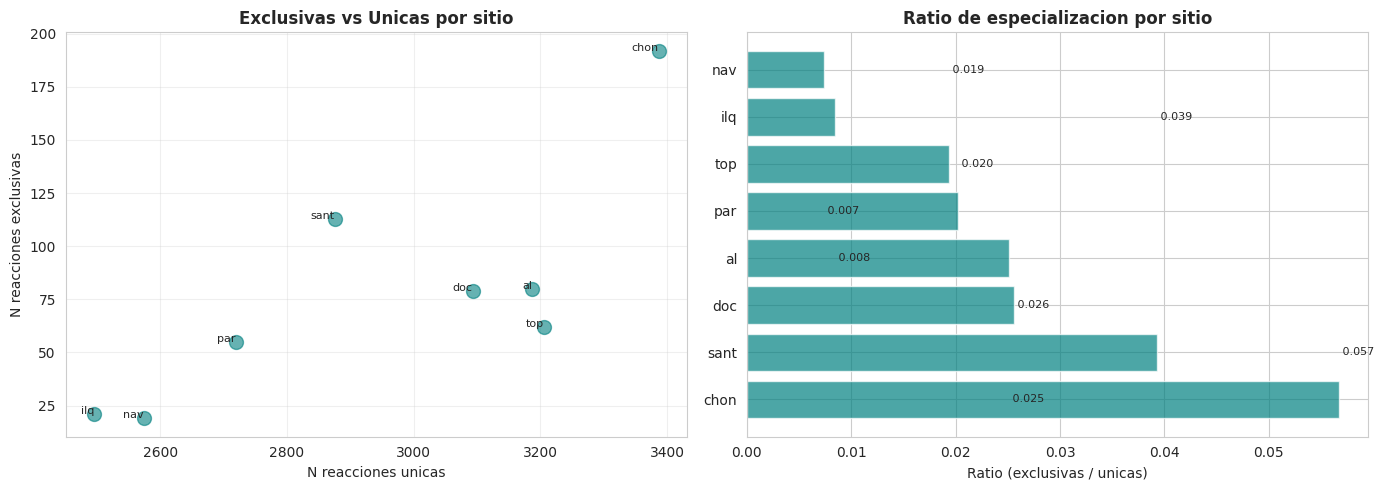


=== 3. FRAGILIDAD GENOMICA: REACCIONES PERDIDAS CON N DELECIONES ===


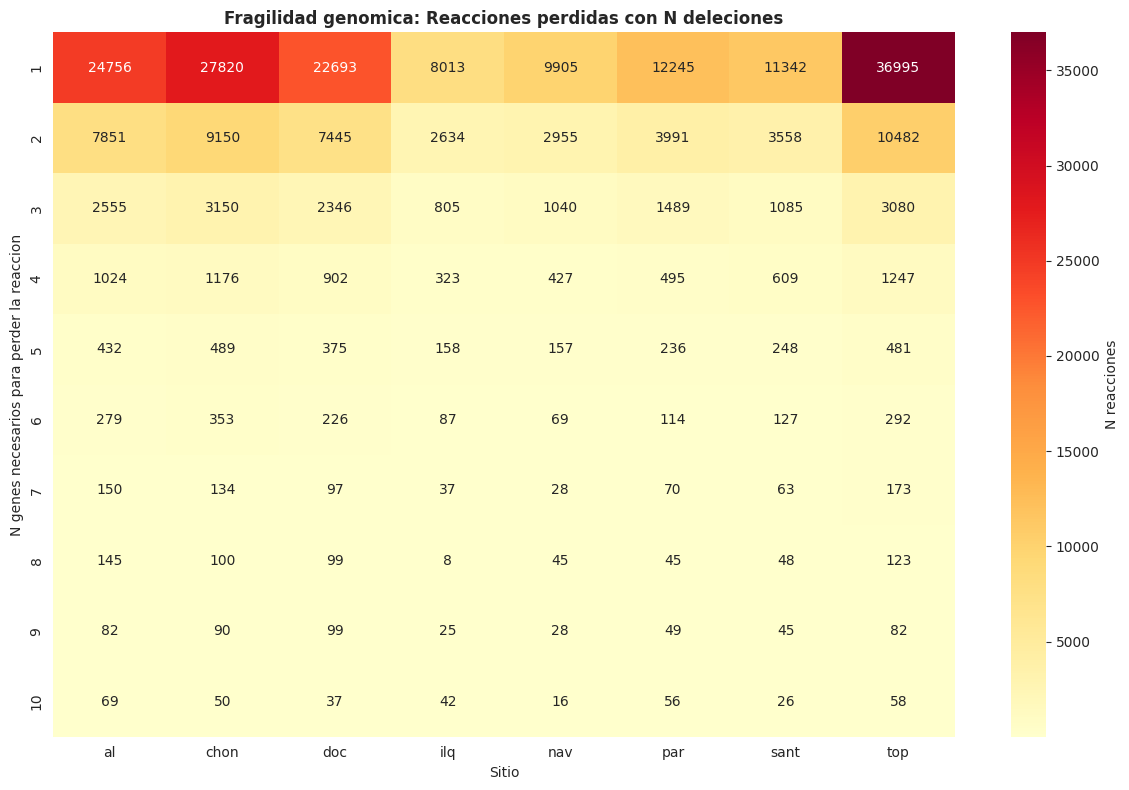

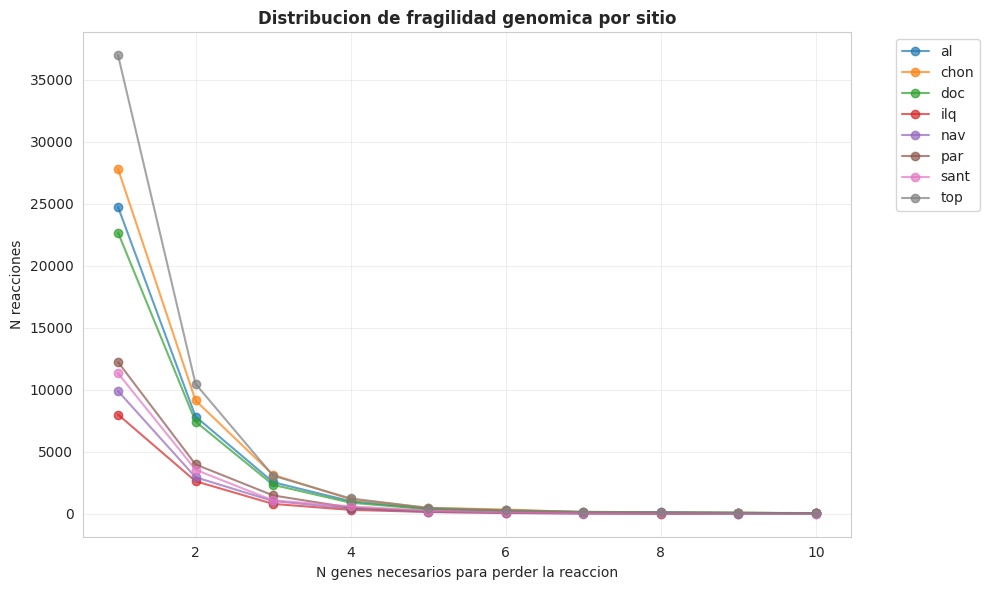

Fragilidad genomica guardada


In [2]:


# ========== 1. MODELOS SIN RIBONUCLEOSIDE TRIPHOSPHATE PHOSPHATASE ==========
print("\n=== 1. MODELOS SIN RIBONUCLEOSIDE TRIPHOSPHATE PHOSPHATASE ===")

rxn_target = "ribonucleoside triphosphate phosphatase"

# Modelos que sí tienen la reacción
modelos_con_rxn = set(
    df[df['rxn_nombre'].str.lower() == rxn_target]['modelo_id'].unique()
)

# Todos los modelos
todos_modelos = set(df['modelo_id'].unique())

# Modelos que NO tienen la reacción
modelos_sin_rxn = sorted(todos_modelos - modelos_con_rxn)

# Crear tabla detallada modelo–sitio
df_sin_rxn = (
    df[df['modelo_id'].isin(modelos_sin_rxn)]
    [['modelo_id', 'sitio']]
    .drop_duplicates()
    .sort_values(['sitio', 'modelo_id'])
    .reset_index(drop=True)
)

# Guardar CSV
df_sin_rxn.to_csv(
    f"{OUT_DIR}/6_modelos_sin_ribonucleoside_triphosphate_phosphatase.csv",
    index=False
)

# Print claro en consola
print(f"Total modelos sin la reaccion: {len(modelos_sin_rxn)} / {len(todos_modelos)}\n")
print(df_sin_rxn)


# ========== 2. RATIO EXCLUSIVAS/UNICAS POR SITIO ==========
print("\n=== 2. RATIO EXCLUSIVAS/UNICAS POR SITIO ===")

df_ratio = df_resumen.merge(df_exclusivas_resumen, on='sitio')
df_ratio['ratio_excl_unicas'] = df_ratio['n_exclusivas'] / df_ratio['n_reacciones']
df_ratio = df_ratio.sort_values('ratio_excl_unicas', ascending=False)
df_ratio.to_csv(f"{OUT_DIR}/7_ratio_exclusivas_unicas.csv", index=False)


# Grafico
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.scatter(df_ratio['n_reacciones'], df_ratio['n_exclusivas'], s=100, alpha=0.6, c='teal')
for _, row in df_ratio.iterrows():
    ax1.annotate(row['sitio'], (row['n_reacciones'], row['n_exclusivas']),
                 fontsize=8, ha='right')
ax1.set_xlabel('N reacciones unicas')
ax1.set_ylabel('N reacciones exclusivas')
ax1.set_title('Exclusivas vs Unicas por sitio', fontweight='bold')
ax1.grid(alpha=0.3)

bars = ax2.barh(df_ratio['sitio'], df_ratio['ratio_excl_unicas'], color='teal', alpha=0.7)
ax2.set_xlabel('Ratio (exclusivas / unicas)')
ax2.set_title('Ratio de especializacion por sitio', fontweight='bold')
for i, row in df_ratio.iterrows():
    ax2.text(row['ratio_excl_unicas'], i, f" {row['ratio_excl_unicas']:.3f}",
             va='center', fontsize=8)

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/7_ratio_exclusivas_unicas.png", dpi=300, bbox_inches='tight')
plt.show()


# ========== 3. FRAGILIDAD: REACCIONES PERDIDAS CON N DELECIONES ==========
print("\n=== 3. FRAGILIDAD GENOMICA: REACCIONES PERDIDAS CON N DELECIONES ===")

fragilidad_por_sitio = []

for sitio in sitios:
    df_s = df[df['sitio'] == sitio].copy()
    n_modelos = df_s['modelo_id'].nunique()

    conteo_deleciones = df_s['min_deleciones'].value_counts().sort_index()

    for n_del in range(1, min(11, conteo_deleciones.index.max() + 1)):
        n_rxn_perdidas = conteo_deleciones[conteo_deleciones.index == n_del].sum()
        fragilidad_por_sitio.append({
            'sitio': sitio,
            'n_deleciones': n_del,
            'n_reacciones': n_rxn_perdidas,
            'n_modelos': n_modelos
        })

df_fragilidad = pd.DataFrame(fragilidad_por_sitio)
df_fragilidad.to_csv(f"{OUT_DIR}/8_fragilidad_genomica.csv", index=False)

# Grafico heatmap
pivot_frag = df_fragilidad.pivot(index='n_deleciones', columns='sitio', values='n_reacciones')
pivot_frag = pivot_frag.fillna(0)

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(pivot_frag, annot=True, fmt='.0f', cmap='YlOrRd', cbar_kws={'label': 'N reacciones'})
ax.set_xlabel('Sitio')
ax.set_ylabel('N genes necesarios para perder la reaccion')
ax.set_title('Fragilidad genomica: Reacciones perdidas con N deleciones', fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/8_fragilidad_genomica_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()

# Grafico de lineas
fig, ax = plt.subplots(figsize=(10, 6))
for sitio in sitios:
    df_sitio = df_fragilidad[df_fragilidad['sitio'] == sitio]
    ax.plot(df_sitio['n_deleciones'], df_sitio['n_reacciones'], marker='o', label=sitio, alpha=0.7)

ax.set_xlabel('N genes necesarios para perder la reaccion')
ax.set_ylabel('N reacciones')
ax.set_title('Distribucion de fragilidad genomica por sitio', fontweight='bold')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/8_fragilidad_genomica_lineas.png", dpi=300, bbox_inches='tight')
plt.show()

print("Fragilidad genomica guardada")




=== REDUNDANCIA EN ENZIMAS ESPECIFICAS DEL CICLO DEL NITROGENO ===


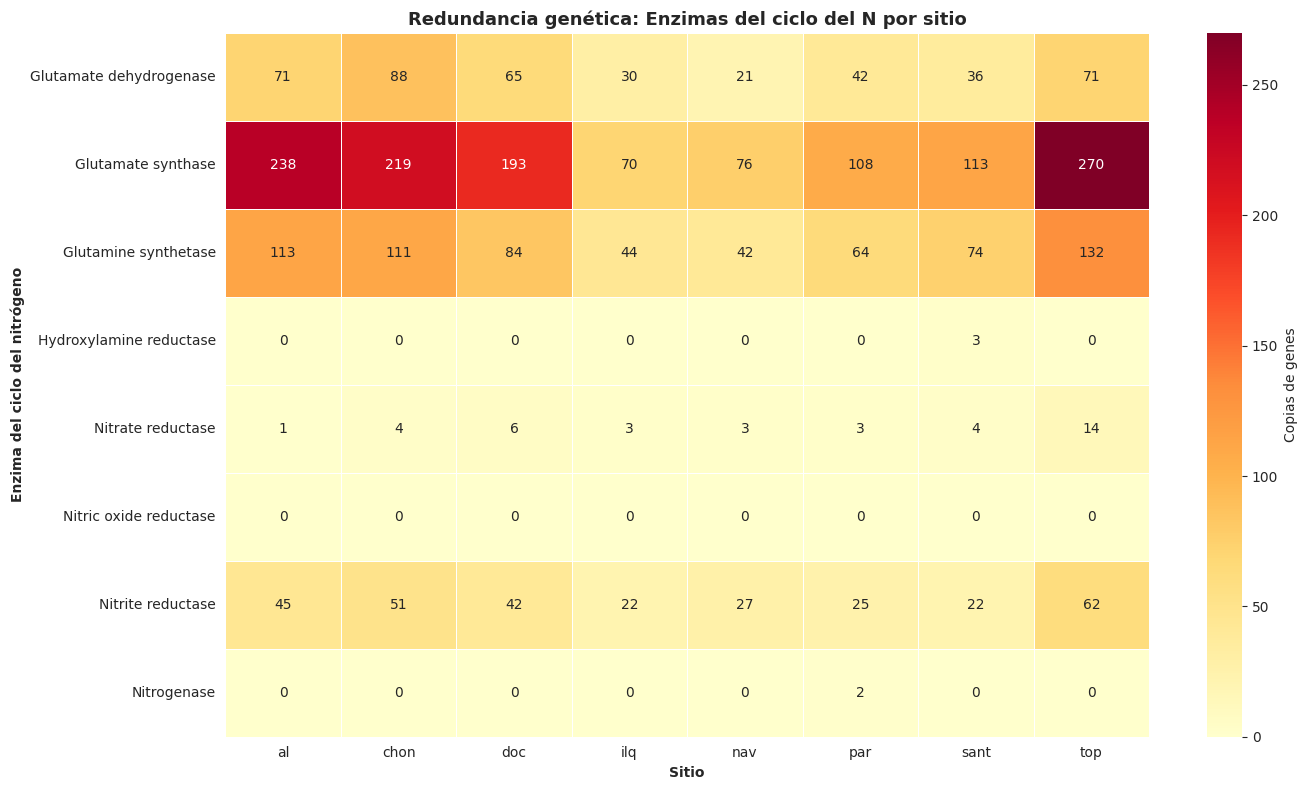

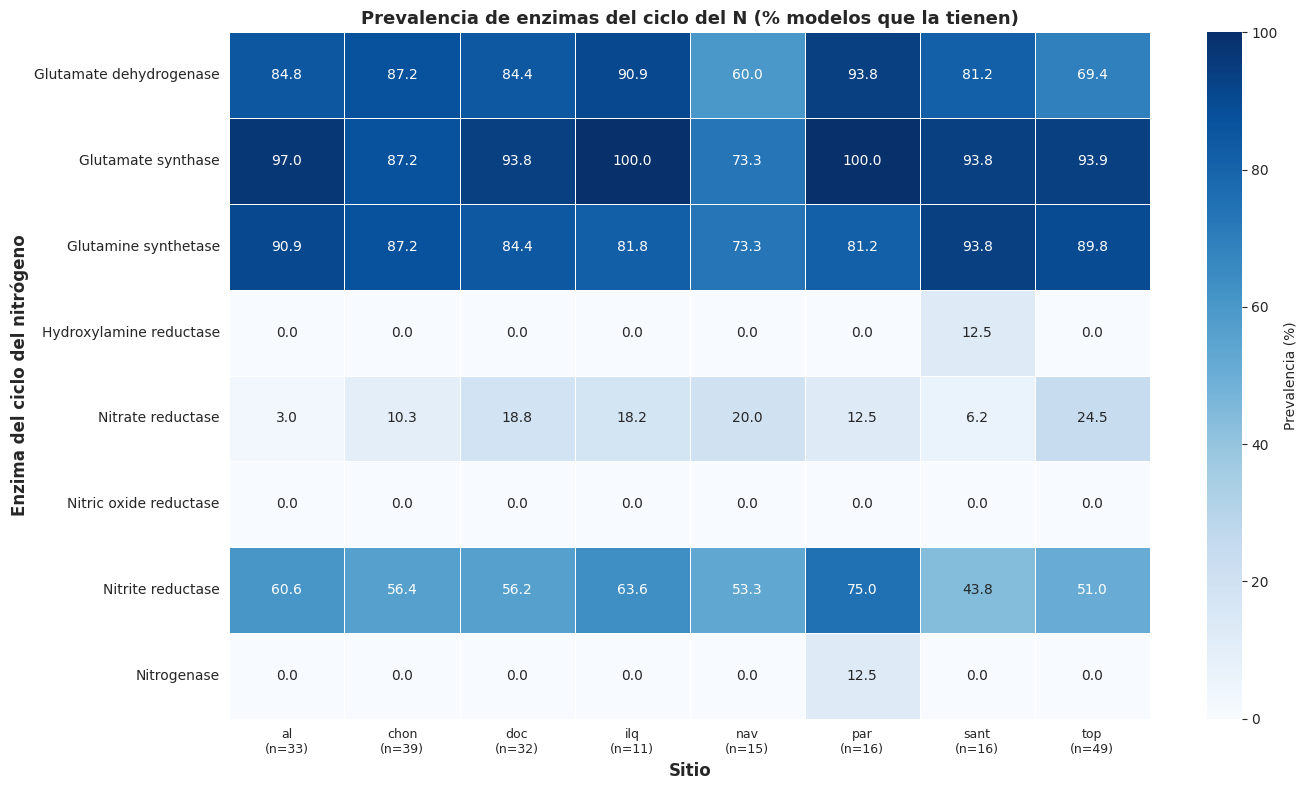


✓ Análisis de enzimas del N completado

=== REDUNDANCIA EN ENZIMAS PRODUCTORAS DE INTERMEDIARIOS CLAVE ===


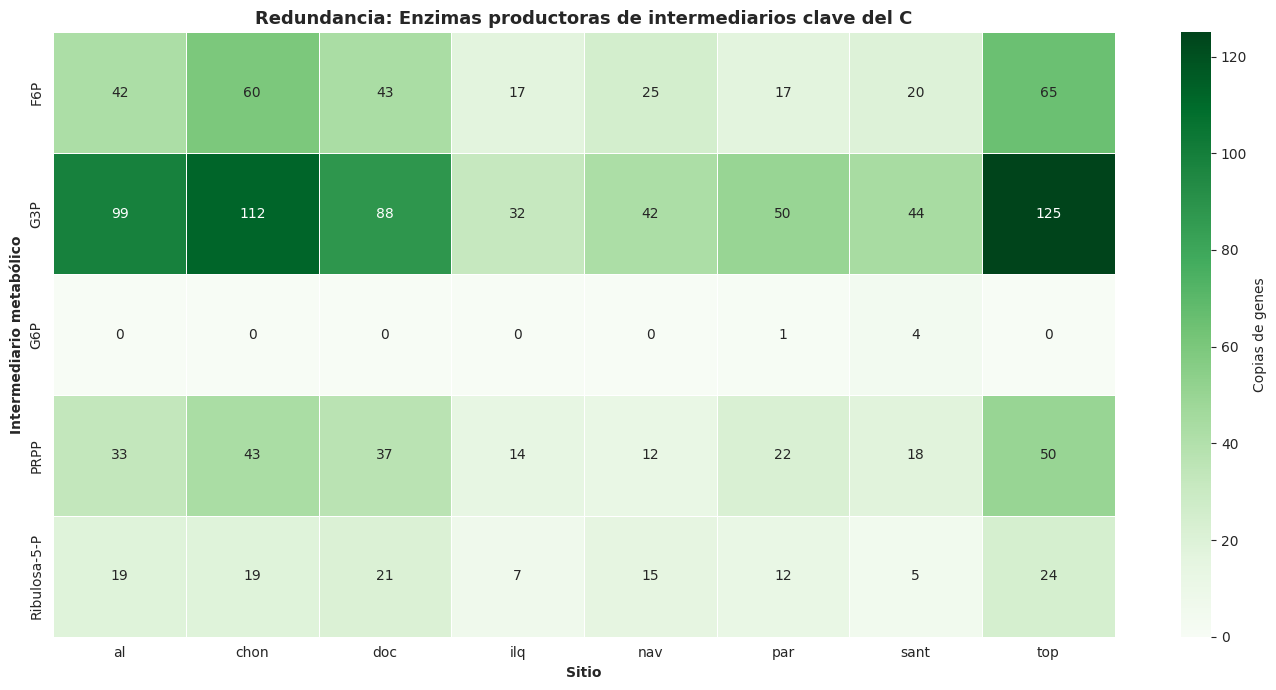


✓ Análisis de intermediarios del C completado


In [3]:
# ========== ANALISIS ESPECIFICO: ENZIMAS DEL CICLO DEL NITROGENO ==========
print("\n=== REDUNDANCIA EN ENZIMAS ESPECIFICAS DEL CICLO DEL NITROGENO ===")

# Definir enzimas clave (buscar por rxn_nombre)
enzimas_N_dict = {
    'Nitrogenase': 'nitrogenase',
    'Nitrate reductase': 'nitrate reductase',
    'Nitrite reductase': 'nitrite reductase',
    'Glutamine synthetase': 'glutamine synthetase',
    'Glutamate synthase': 'glutamate synthase',
    'Glutamate dehydrogenase': 'glutamate dehydrogenase',
    'Hydroxylamine reductase': 'hydroxylamine reductase',
    'Nitric oxide reductase': 'nitric-oxide reductase'
}

#############################################
# Verificar qué reacciones estás capturando
# Revisar si hay falsos positivos o falsos negativos
#keyword = 'glutamine synthetase'
#matches = df[df['rxn_nombre'].str.contains(keyword, case=False, na=False)][['rxn_nombre', 'rxn_id', 'ec']].drop_duplicates()
#print(f"\nReacciones capturadas por '{keyword}':")
#print(matches)
#############################################

# Análisis por sitio
redundancia_N_detallada = []

for sitio in sitios:
    df_s = df[df['sitio'] == sitio].copy()
    n_modelos_sitio = df_s['modelo_id'].nunique()

    for enzima_nombre, enzima_keyword in enzimas_N_dict.items():
        # Buscar reacciones que contengan la enzima
        df_enzima = df_s[df_s['rxn_nombre'].str.contains(enzima_keyword, case=False, na=False)]

        if not df_enzima.empty:
            redundancia_N_detallada.append({
                'sitio': sitio,
                'enzima': enzima_nombre,
                'n_modelos_con_enzima': df_enzima['modelo_id'].nunique(),
                'prevalencia_pct': (df_enzima['modelo_id'].nunique() / n_modelos_sitio) * 100,
                'genes_total': df_enzima['min_deleciones'].sum(),
                'genes_promedio_por_modelo': df_enzima['min_deleciones'].sum() / df_enzima['modelo_id'].nunique(),
                'genes_max': df_enzima['min_deleciones'].max(),
                'genes_min': df_enzima['min_deleciones'].min(),
                'n_reacciones': len(df_enzima)
            })
        else:
            # Si no está presente, registrar como 0
            redundancia_N_detallada.append({
                'sitio': sitio,
                'enzima': enzima_nombre,
                'n_modelos_con_enzima': 0,
                'prevalencia_pct': 0,
                'genes_total': 0,
                'genes_promedio_por_modelo': 0,
                'genes_max': 0,
                'genes_min': 0,
                'n_reacciones': 0
            })

df_N_detallado = pd.DataFrame(redundancia_N_detallada)
df_N_detallado.to_csv(f"{OUT_DIR}/14_redundancia_nitrogeno_detallado.csv", index=False)

# GRAFICO 1: Heatmap de genes totales por enzima y sitio
pivot_N_genes = df_N_detallado.pivot(index='enzima', columns='sitio', values='genes_total')
pivot_N_genes = pivot_N_genes.fillna(0)

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(pivot_N_genes, annot=True, fmt='.0f', cmap='YlOrRd',
            cbar_kws={'label': 'Copias de genes'}, linewidths=0.5)
ax.set_xlabel('Sitio', fontweight='bold')
ax.set_ylabel('Enzima del ciclo del nitrógeno', fontweight='bold')
ax.set_title('Redundancia genética: Enzimas del ciclo del N por sitio',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/14_heatmap_enzimas_nitrogeno.png", dpi=300, bbox_inches='tight')
plt.show()

# GRAFICO 2: Heatmap de prevalencia (% modelos con la enzima)
pivot_N_prev = df_N_detallado.pivot(index='enzima', columns='sitio', values='prevalencia_pct')
pivot_N_prev = pivot_N_prev.fillna(0)

# NUEVO: Calcular número de modelos por sitio para las etiquetas
n_modelos_por_sitio = df.groupby('sitio')['modelo_id'].nunique().to_dict()
sitios_labels = [f"{sitio}\n(n={n_modelos_por_sitio[sitio]})" for sitio in pivot_N_prev.columns]

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(pivot_N_prev, annot=True, fmt='.1f', cmap='Blues',
            cbar_kws={'label': 'Prevalencia (%)'}, linewidths=0.5, vmin=0, vmax=100)

ax.set_xlabel('Sitio', fontweight='bold', fontsize=12)
ax.set_ylabel('Enzima del ciclo del nitrógeno', fontweight='bold', fontsize=12)
ax.set_title('Prevalencia de enzimas del ciclo del N (% modelos que la tienen)',
             fontweight='bold', fontsize=13)

# NUEVO: Aplicar etiquetas con número de modelos
ax.set_xticklabels(sitios_labels, rotation=0, ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/14_heatmap_prevalencia_nitrogeno.png", dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Análisis de enzimas del N completado")

# ========== ANALISIS: ENZIMAS QUE PRODUCEN G3P, PRPP, F6P, ETC ==========
print("\n=== REDUNDANCIA EN ENZIMAS PRODUCTORAS DE INTERMEDIARIOS CLAVE ===")

# Buscar reacciones que PRODUCEN estos metabolitos (aparecen después de -->)
intermediarios_target = {
    'G3P': ['GAP_c', 'GLYCERALDEHYDE-3-PHOSPHATE'],
    'F6P': ['FRUCTOSE-6P_c', 'FRUCTOSE__45__6P'],
    'G6P': ['GLC-6-P_c', 'GLUCOS__45__6'],
    'PRPP': ['PRPP_c'],
    'Ribulosa-5-P': ['RIBULOSE-5P_c', 'RIBULOSE__45__5P']
}

redundancia_intermediarios = []

for int_nombre, int_keywords in intermediarios_target.items():
    for sitio in sitios:
        df_s = df[df['sitio'] == sitio].copy()
        n_modelos_sitio = df_s['modelo_id'].nunique()

        # Buscar reacciones que producen el intermediario (después de -->)
        mask_produccion = df_s['estequiometria'].str.contains('-->', na=False)
        df_produccion = df_s[mask_produccion].copy()

        # Filtrar las que tienen el metabolito en productos
        df_int = df_produccion[
            df_produccion['estequiometria'].apply(
                lambda x: any(kw in str(x).split('-->')[1] if '-->' in str(x) else False
                             for kw in int_keywords)
            )
        ]

        if not df_int.empty:
            redundancia_intermediarios.append({
                'sitio': sitio,
                'intermediario': int_nombre,
                'n_reacciones': len(df_int),
                'n_modelos': df_int['modelo_id'].nunique(),
                'genes_total': df_int['min_deleciones'].sum(),
                'genes_promedio': df_int['min_deleciones'].mean(),
                'prevalencia_pct': (df_int['modelo_id'].nunique() / n_modelos_sitio) * 100
            })
        else:
            redundancia_intermediarios.append({
                'sitio': sitio,
                'intermediario': int_nombre,
                'n_reacciones': 0,
                'n_modelos': 0,
                'genes_total': 0,
                'genes_promedio': 0,
                'prevalencia_pct': 0
            })

df_intermediarios = pd.DataFrame(redundancia_intermediarios)
df_intermediarios.to_csv(f"{OUT_DIR}/15_redundancia_intermediarios_carbono.csv", index=False)

# Heatmap de genes totales
pivot_int = df_intermediarios.pivot(index='intermediario', columns='sitio', values='genes_total')
pivot_int = pivot_int.fillna(0)

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(pivot_int, annot=True, fmt='.0f', cmap='Greens',
            cbar_kws={'label': 'Copias de genes'}, linewidths=0.5)
ax.set_xlabel('Sitio', fontweight='bold')
ax.set_ylabel('Intermediario metabólico', fontweight='bold')
ax.set_title('Redundancia: Enzimas productoras de intermediarios clave del C',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/15_heatmap_intermediarios_carbono.png", dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Análisis de intermediarios del C completado")





=== TABLA RESUMEN: ROBUSTEZ POR VIA METABOLICA ===

                            via  prevalencia_pct  n_modelos  redundancia_total  fragilidad_promedio  fragilidad_min  n_sitios_presentes clasificacion_robustez
Asimilación NH4+ (GS+GOGAT+GDH)        95.734597        202               2375             1.906100               1                   8            MUY ROBUSTA
                            PPP        96.208531        203               1021             1.578053               1                   8            MUY ROBUSTA
                 Producción G3P        94.786730        200                634             1.498818               1                   8            MUY ROBUSTA
      Glucólisis (F6P→Piruvato)        93.838863        198                624             1.255533               1                   8            MUY ROBUSTA
                 Reducción NO2-        56.398104        119                296             1.617486               1                   8                R

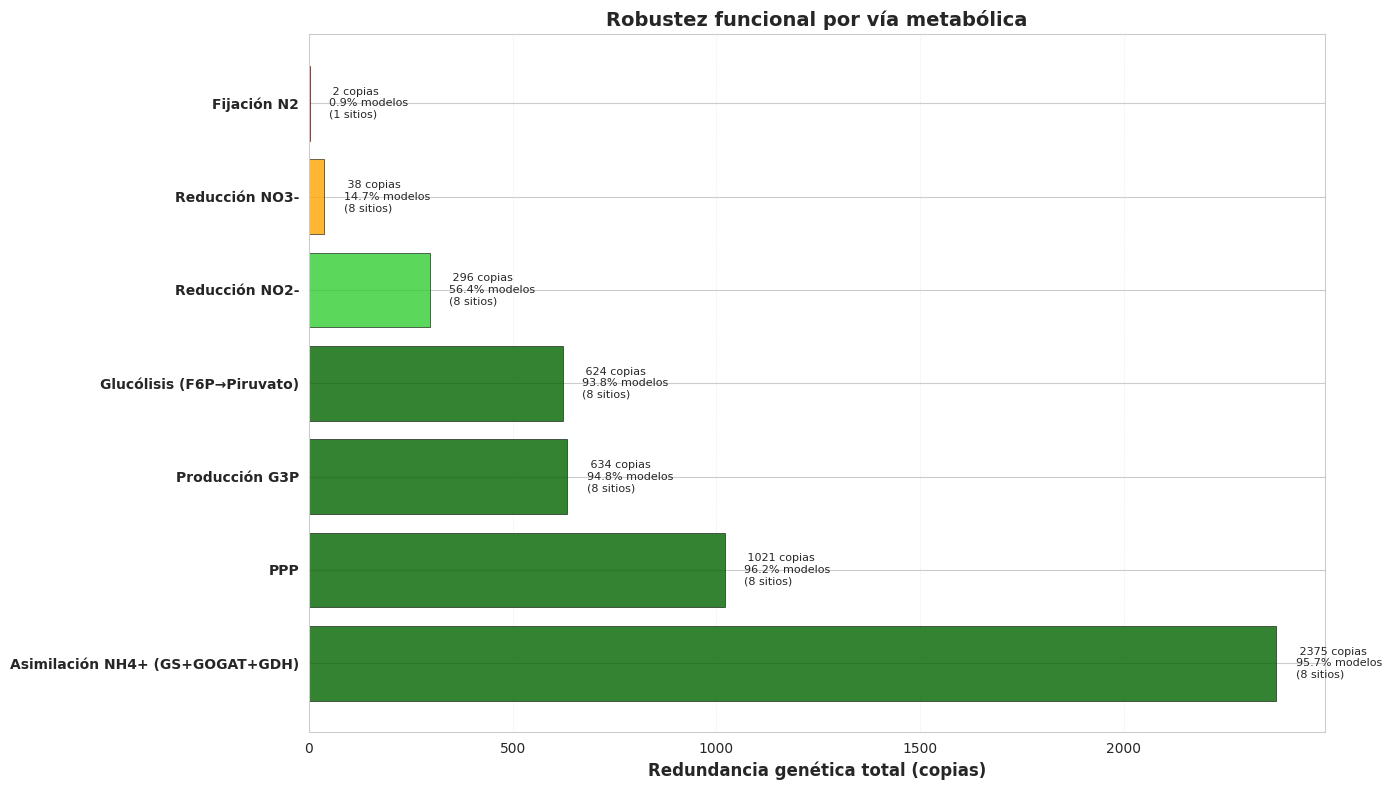

In [4]:
# ========== TABLA RESUMEN: ROBUSTEZ POR VIA METABOLICA ==========
print("\n=== TABLA RESUMEN: ROBUSTEZ POR VIA METABOLICA ===")

vias_analisis = {
    'Asimilación NH4+ (GS+GOGAT+GDH)': ['glutamine synthetase', 'glutamate synthase', 'glutamate dehydrogenase'],
    'Fijación N2': ['nitrogenase'],
    'Reducción NO3-': ['nitrate reductase'],
    'Reducción NO2-': ['nitrite reductase'],
    'Producción G3P': ['glyceraldehyde-3-phosphate dehydrogenase', 'triose-phosphate isomerase'],
    'Glucólisis (F6P→Piruvato)': ['phosphofructokinase', 'pyruvate kinase', 'enolase'],
    'PPP': ['glucose-6-phosphate dehydrogenase', 'transketolase', 'transaldolase']
}

resumen_vias = []

for via_nombre, enzimas_keywords in vias_analisis.items():
    # Buscar todas las reacciones de la vía
    mask = df['rxn_nombre'].str.contains('|'.join(enzimas_keywords), case=False, na=False)
    df_via = df[mask].copy()

    if not df_via.empty:
        n_modelos_con_via = df_via['modelo_id'].nunique()
        prevalencia = (n_modelos_con_via / df['modelo_id'].nunique()) * 100
        redundancia_total = df_via['min_deleciones'].sum()
        fragilidad_promedio = df_via['min_deleciones'].mean()
        fragilidad_min = df_via['min_deleciones'].min()
        n_sitios = df_via['sitio'].nunique()

        # Clasificación de robustez
        if prevalencia >= 70 and redundancia_total >= 100:
            clasificacion = "MUY ROBUSTA"
        elif prevalencia >= 40 and redundancia_total >= 50:
            clasificacion = "ROBUSTA"
        elif prevalencia >= 15:
            clasificacion = "MODERADA"
        elif prevalencia >= 5:
            clasificacion = "FRÁGIL"
        else:
            clasificacion = "EXTREMADAMENTE FRÁGIL"
    else:
        n_modelos_con_via = 0
        prevalencia = 0
        redundancia_total = 0
        fragilidad_promedio = 0
        fragilidad_min = 0
        n_sitios = 0
        clasificacion = "AUSENTE"

    resumen_vias.append({
        'via': via_nombre,
        'prevalencia_pct': prevalencia,
        'n_modelos': n_modelos_con_via,
        'redundancia_total': redundancia_total,
        'fragilidad_promedio': fragilidad_promedio,
        'fragilidad_min': fragilidad_min,
        'n_sitios_presentes': n_sitios,
        'clasificacion_robustez': clasificacion
    })

df_resumen_vias = pd.DataFrame(resumen_vias).sort_values('redundancia_total', ascending=False)
df_resumen_vias.to_csv(f"{OUT_DIR}/18_resumen_robustez_vias.csv", index=False)

print("\n" + "="*100)
print(df_resumen_vias.to_string(index=False))
print("="*100)

# Gráfico de clasificación SIN leyenda dentro del plot
fig, ax = plt.subplots(figsize=(14, 8))

colores = {
    'MUY ROBUSTA': 'darkgreen',
    'ROBUSTA': 'limegreen',
    'MODERADA': 'gold',
    'FRÁGIL': 'orange',
    'EXTREMADAMENTE FRÁGIL': 'red',
    'AUSENTE': 'gray'
}

y_pos = np.arange(len(df_resumen_vias))
colors = [colores[c] for c in df_resumen_vias['clasificacion_robustez']]

bars = ax.barh(y_pos, df_resumen_vias['redundancia_total'], color=colors, alpha=0.8, edgecolor='black', linewidth=0.5)
ax.set_yticks(y_pos)
ax.set_yticklabels(df_resumen_vias['via'], fontsize=10, fontweight='bold')
ax.set_xlabel('Redundancia genética total (copias)', fontweight='bold', fontsize=12)
ax.set_title('Robustez funcional por vía metabólica',
             fontweight='bold', fontsize=14)

# Anotaciones
for i, row in enumerate(df_resumen_vias.itertuples()):
    if row.redundancia_total > 0:
        x_pos = row.redundancia_total + (max(df_resumen_vias['redundancia_total']) * 0.02)
        label = f"{int(row.redundancia_total)} copias\n{row.prevalencia_pct:.1f}% modelos\n({row.n_sitios_presentes} sitios)"
        ax.text(x_pos, i, f' {label}', va='center', fontsize=8)

# Grid sutil
ax.grid(axis='x', alpha=0.3, linestyle='--', linewidth=0.5)
ax.set_axisbelow(True)

# SIN LEYENDA - la cajita desaparece
# (simplemente comentar o eliminar ax.legend())

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/18_robustez_vias_clasificado.png", dpi=300, bbox_inches='tight')
plt.show()